## <span style="color:#1a73e8">Houskeeping: Load packages and datasets, clean dataframes, etc.</span>

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import os.path as op
import glob
import matplotlib.pyplot as plt
import ast
import csv
import random
%matplotlib inline
import scipy
from matplotlib.cm import get_cmap
from plot_utils import combined_rolling_average_and_model_fit_linear, combined_rolling_average_and_model_fit_general
from common_functions import remove_unit_variance
from sklearn.preprocessing import scale

In [2]:
# scaler = StandardScaler()

# Update to your file path
df = pd.read_csv('../data/wm_task_questionnaires.csv')
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns


/var/folders/4_/n1p8tswd39b0jr38l2pdhr4r0000gn/T/ipykernel_29171/2103431541.py:4: DtypeWarning: Columns (254,255,256,257,258,259) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/wm_task_questionnaires.csv')


In [3]:
# 1. Create categorical questionnaire variables based on tertiles
def categorize_by_tertiles(series):
    q1 = series.quantile(1/3)
    q2 = series.quantile(2/3)
    return pd.cut(series, bins=[-np.inf, q1, q2, np.inf], labels=["low", "medium", "high"])

df["vviq_cat"] = categorize_by_tertiles(df["vviq_sum"])
df["osivq_visual_cat"] = categorize_by_tertiles(df["osivq_visual_mean"])
df["osivq_verbal_cat"] = categorize_by_tertiles(df["osivq_verbal_mean"])
df["osivq_spatial_cat"] = categorize_by_tertiles(df["osivq_spatial_mean"])
df["irq_visual_cat"] = categorize_by_tertiles(df["irq_visual_mean"])
df["irq_verbal_cat"] = categorize_by_tertiles(df["irq_verbal_mean"])

cat_order = pd.CategoricalDtype(categories=["low", "medium", "high"], ordered=True)
df["vviq_cat"] = df["vviq_cat"].astype(cat_order)
df["irq_visual_cat"] = df["irq_visual_cat"].astype(cat_order)
df["irq_verbal_cat"] = df["irq_verbal_cat"].astype(cat_order)

# 3. Filter correct trials
df_correct = df[df["resp_correct"] == 1].copy()

# 4. Standardize selected variables in df_correct
variables_to_scale = [
    "it_sim_dis_test_z", "it_sim_dis_test_sq_z",
    "it_sim_dis_diff_test_z", "it_sim_dis_diff_test_sq_z",
    "validity_reliability_z",
    "v2_sim_dis_test_z", "v2_sim_dis_test_sq_z",
    "v2_sim_dis_diff_test_z", "v2_sim_dis_diff_test_sq_z",
    "it_sim_dis_diff_test_sign_z", "it_sim_dis_diff_test_sign_sq_z",
    "v2_sim_dis_diff_test_sign_z", "v2_sim_dis_diff_test_sign_sq_z"
]

for var in variables_to_scale:
    if var in df_correct.columns:
        df_correct[var] = scale(df_correct[var].astype(float), with_mean=True, with_std=True)
    else:
        print(f"Warning: '{var}' not found in df_correct")



In [4]:
df['it_pos_neg'] =  np.where(df['it_sim_dis_diff_test'] <= 0, 0, 1)
df['v2_pos_neg'] =  np.where(df['v2_sim_dis_diff_test'] <= 0, 0, 1)
df_correct = df[df['resp_correct'] == 1]
#this approach here seems more correct
df_correct['wm_rt'] = np.log(df_correct['mouse.time_last'])
df_correct = remove_unit_variance(df_correct,'wm_rt', 'participant')
df_correct['WM RT'] = df_correct['wm_rt_within']


/var/folders/4_/n1p8tswd39b0jr38l2pdhr4r0000gn/T/ipykernel_29171/102014522.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_correct['wm_rt'] = np.log(df_correct['mouse.time_last'])


In [5]:
# Update to your file path

df_errors = pd.read_csv('../data/df_errors.csv')

/var/folders/4_/n1p8tswd39b0jr38l2pdhr4r0000gn/T/ipykernel_29171/537710490.py:3: DtypeWarning: Columns (157,254,255,256,257,258,259) have mixed types. Specify dtype option on import or set low_memory=False.
  df_errors = pd.read_csv('../data/df_errors.csv')


In [6]:
df_errors['participant'].nunique()


246

In [7]:
# Drop rows where 'failed_check_count' == 3 from df
df = df[df['failed_check_count'] != 3]

# Drop rows where 'failed_check_count' is either 2 or 3 from df_errors
df_errors = df_errors[~df_errors['failed_check_count'].isin([2, 3])]


In [8]:
df_errors['participant'].nunique()
df['participant'].nunique()


246

In [9]:
df['tested_memorability_binned'] = pd.qcut(df['tested_memorability_resmem'], q=3, 
                                           labels=['Weak','Moderate', 'Strong'])
df['v2_similarity_binned'] = pd.qcut(df['v2_sim_dis_test_z'], q=3, 
                                           labels=['Weak','Moderate', 'Strong'])


df_correct['tested_memorability_binned'] = pd.qcut(df_correct['tested_memorability_resmem'], q=3, 
                                           labels=['Weak','Moderate', 'Strong'])
df_correct['v2_similarity_binned'] = pd.qcut(df_correct['v2_sim_dis_test_z'], q=3, 
                                           labels=['Weak','Moderate', 'Strong'])


df_errors['tested_memorability_binned'] = pd.qcut(df_errors['tested_memorability_resmem'], q=3, 
                                           labels=['Weak','Moderate', 'Strong'])
df_errors['v2_similarity_binned'] = pd.qcut(df_errors['v2_sim_dis_test_z'], q=3, 
                                           labels=['Weak','Moderate', 'Strong'])
df_errors["vviq_cat"] = categorize_by_tertiles(df_errors["vviq_sum"])
df_errors["osivq_visual_cat"] = categorize_by_tertiles(df_errors["osivq_visual_mean"])
df_errors["osivq_verbal_cat"] = categorize_by_tertiles(df_errors["osivq_verbal_mean"])
df_errors["osivq_spatial_cat"] = categorize_by_tertiles(df_errors["osivq_spatial_mean"])
df_errors["irq_visual_cat"] = categorize_by_tertiles(df_errors["irq_visual_mean"])
df_errors["irq_verbal_cat"] = categorize_by_tertiles(df_errors["irq_verbal_mean"])

cat_order = pd.CategoricalDtype(categories=["low", "medium", "high"], ordered=True)
df_errors["vviq_cat"] = df_errors["vviq_cat"].astype(cat_order)
df_errors["irq_visual_cat"] = df_errors["irq_visual_cat"].astype(cat_order)
df_errors["irq_verbal_cat"] = df_errors["irq_verbal_cat"].astype(cat_order)

In [10]:
sns.set_context('notebook')

In [11]:
palette_dict = {
    "invalid": "#084594",   # Navy
    "valid": "#D9D9D9",     # Light gray
}

# Visual measures — navy
palette_visual = {
    "valid":   "#8BA4C0",   # Lighter navy
    "invalid": "#506488",   # Navy (used as base for lighten/darken)
}

# Verbal measures — gold
palette_verbal = {
    "valid":   "#D4BC73",   # Lighter gold
    "invalid": "#B08B27",   # Gold (used as base for lighten/darken)
}

# VVIQ uses the visual (navy) scheme
palette_vviq = palette_visual


## <span style="color:#1a73e8">Useful functions</span>

In [12]:
def create_combined_imagery_validity_facet_plot(
    df_correct, df, df_errors, palette_visual, palette_verbal,
    figsize=None, filename_prefix="combined_imagery",
    style_mode="dashed",   # "dashed" or "open_circles"
    rt_mode="ms",          # "ms" or "log"
    rt_ylim=None           # optional; useful for log RT
):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    import matplotlib.ticker as mticker
    from matplotlib.lines import Line2D

    ONE_COL_IN = 3.50
    if figsize is None:
        width_in  = ONE_COL_IN
        height_in = ONE_COL_IN * 0.75
        figsize   = (width_in, height_in)

    plt.rcParams.update({
        "font.family": "Helvetica",
        "font.size": 8,
        "axes.labelsize": 8,
        "axes.titlesize": 9,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "lines.linewidth": 0.9,
    })

    marker_size = 4
    reg_line_width = 1
    err_bar_thickness = 0.8
    prioritized_outline_width = 0.25
    deprioritized_outline_width = 0.25

    deprioritized_dash = (0, (1.5, 1.0))

    def hex_to_rgb(hex_color):
        hex_color = hex_color.lstrip("#")
        return np.array([int(hex_color[i:i+2], 16) / 255 for i in (0, 2, 4)])

    def rgb_to_hex(rgb):
        rgb = np.clip(rgb, 0, 1)
        return "#" + "".join(f"{int(c * 255):02X}" for c in rgb)

    def lighten(hex_color, factor=0.25):
        rgb = hex_to_rgb(hex_color)
        rgb = rgb + (1 - rgb) * factor
        return rgb_to_hex(rgb)

    def darken(hex_color, factor=0.20):
        rgb = hex_to_rgb(hex_color)
        rgb = rgb * (1 - factor)
        return rgb_to_hex(rgb)

    # Use the palette inputs you pass in
    VISUAL_BASE = palette_visual.get("invalid", "#506488")
    VERBAL_BASE = palette_verbal.get("invalid", "#B08B27")

    def get_colors_for_variable(var_name):
        base_color = VERBAL_BASE if "verbal" in var_name.lower() else VISUAL_BASE

        # Prioritized = lighter
        # Deprioritized = darker
        prioritized_color   = lighten(base_color, 0.22)
        deprioritized_color = darken(base_color, 0.15)

        return prioritized_color, deprioritized_color

    rng = np.random.default_rng(123)

    def bootstrap_mean_ci(values, n_boot=1000):
        values = np.asarray(values)
        values = values[np.isfinite(values)]

        if len(values) == 0:
            return np.nan, np.nan, np.nan

        mean_val = np.mean(values)

        if len(values) == 1:
            return mean_val, 0, 0

        boot_means = rng.choice(values, size=(n_boot, len(values)), replace=True).mean(axis=1)
        lo, hi = np.percentile(boot_means, [2.5, 97.5])

        return mean_val, mean_val - lo, hi - mean_val

    def plot_binned_points(
        ax, data, x_col, y_col, bins, color,
        filled=True, marker_size=3.0, outline_width=0.4
    ):
        sub = data[[x_col, y_col]].dropna().copy()
        if sub.empty:
            return

        centers = np.asarray(bins)
        mids = (centers[:-1] + centers[1:]) / 2
        edges = np.r_[-np.inf, mids, np.inf]

        xs, ys, yerr_low, yerr_high = [], [], [], []

        for idx, center in enumerate(centers):
            bin_vals = sub.loc[
                (sub[x_col] > edges[idx]) & (sub[x_col] <= edges[idx + 1]),
                y_col
            ].to_numpy()

            if len(bin_vals) == 0:
                continue

            mean_y, low_err, high_err = bootstrap_mean_ci(bin_vals)

            xs.append(center)
            ys.append(mean_y)
            yerr_low.append(low_err)
            yerr_high.append(high_err)

        if len(xs) == 0:
            return

        markerface = color if filled else "none"

        ax.errorbar(
            xs,
            ys,
            yerr=np.vstack([yerr_low, yerr_high]),
            fmt="o",
            markersize=marker_size,
            markerfacecolor=markerface,
            markeredgecolor=color,
            markeredgewidth=outline_width,
            ecolor=color,
            elinewidth=err_bar_thickness,
            capsize=0,
            linestyle="none",
            alpha=0.9,
            zorder=4
        )

    df_correct_rt = df_correct.copy()

    if rt_mode == "ms":
        df_correct_rt["rt_plot"] = df_correct_rt["rt"] * 1000
        rt_y_col = "rt_plot"
        rt_ylabel = "Response Time\n(Milliseconds)"
        rt_default_ylim = (1300, 1800)
        rt_formatter = mticker.FuncFormatter(lambda y, _: f"{y:.0f}")

    elif rt_mode == "log":
        df_correct_rt = df_correct_rt[
            df_correct_rt["rt"].notna() & (df_correct_rt["rt"] > 0)
        ].copy()
        df_correct_rt["rt_plot"] = np.log(df_correct_rt["rt"])
        rt_y_col = "rt_plot"
        rt_ylabel = "Log Response\nTime"
        rt_default_ylim = None
        rt_formatter = mticker.FuncFormatter(lambda y, _: f"{y:.2f}")

    else:
        raise ValueError("rt_mode must be either 'ms' or 'log'")

    variables = ['irq_visual_mean', 'osivq_visual_mean', 'irq_verbal_mean', 'osivq_verbal_mean']
    variable_labels = ['IRQ Visual', 'OSIVQ Visual', 'IRQ Verbal', 'OSIVQ Verbal']

    fig, axes = plt.subplots(3, 4, figsize=(3.67, 3.0), dpi=300)

    significance = {
        (0, 0): '*', (0, 1): '*', (0, 3): '**',
        (1, 3): '***', (2, 1): '*', (2, 3): '***',
    }

    def plot_validity_panel(ax, data, x_var, y_var, bins):
        prioritized_color, deprioritized_color = get_colors_for_variable(x_var)

        valid_data = data[data["validity"] == "valid"]
        invalid_data = data[data["validity"] == "invalid"]

        if style_mode == "dashed":
            prioritized_linestyle = "-"
            deprioritized_linestyle = deprioritized_dash
            prioritized_filled = True
            deprioritized_filled = True

        elif style_mode == "open_circles":
            prioritized_linestyle = "-"
            deprioritized_linestyle = "-"
            prioritized_filled = True
            deprioritized_filled = False

        else:
            raise ValueError("style_mode must be 'dashed' or 'open_circles'")

        sns.regplot(
            data=valid_data,
            x=x_var,
            y=y_var,
            ax=ax,
            scatter=False,
            ci=95,
            color=prioritized_color,
            line_kws={
                "linewidth": reg_line_width,
                "linestyle": prioritized_linestyle
            }
        )

        sns.regplot(
            data=invalid_data,
            x=x_var,
            y=y_var,
            ax=ax,
            scatter=False,
            ci=95,
            color=deprioritized_color,
            line_kws={
                "linewidth": reg_line_width,
                "linestyle": deprioritized_linestyle
            }
        )

        plot_binned_points(
            ax,
            valid_data,
            x_var,
            y_var,
            bins,
            prioritized_color,
            filled=prioritized_filled,
            marker_size=marker_size,
            outline_width=prioritized_outline_width
        )

        plot_binned_points(
            ax,
            invalid_data,
            x_var,
            y_var,
            bins,
            deprioritized_color,
            filled=deprioritized_filled,
            marker_size=marker_size,
            outline_width=deprioritized_outline_width
        )

    # ROW 1: RT ---------------------------------------------------------
    for i, (var, label) in enumerate(zip(variables, variable_labels)):
        bins = np.linspace(df_correct_rt[var].min(), df_correct_rt[var].max(), 5)

        plot_validity_panel(axes[0, i], df_correct_rt, var, rt_y_col, bins)

        axes[0, i].set_xlim(0.8, 5.2)
        axes[0, i].set_xticks([1, 2, 3, 4, 5])

        if rt_ylim is not None:
            axes[0, i].set_ylim(rt_ylim)
        elif rt_default_ylim is not None:
            axes[0, i].set_ylim(rt_default_ylim)

        axes[0, i].yaxis.set_major_formatter(rt_formatter)

        axes[0, i].set_xlabel("", fontsize=6)
        axes[0, i].set_ylabel(rt_ylabel if i == 0 else "", fontsize=6)

        axes[0, i].spines['top'].set_visible(False)
        axes[0, i].spines['right'].set_visible(False)
        axes[0, i].spines['bottom'].set_visible(False)
        axes[0, i].tick_params(axis='x', labelbottom=False, bottom=False)

        if i > 0:
            axes[0, i].spines['left'].set_visible(False)
            axes[0, i].tick_params(axis='y', labelleft=False, left=False)

        axes[0, i].tick_params(axis='both', labelsize=5)

        if (0, i) in significance:
            # Put asterisks near the top of current axis range
            y0, y1 = axes[0, i].get_ylim()
            axes[0, i].text(
                3,
                y0 + 0.93 * (y1 - y0),
                significance[(0, i)],
                ha='center',
                va='center',
                fontsize=12,
                fontweight='bold'
            )

    # ROW 2: Accuracy ---------------------------------------------------
    for i, (var, label) in enumerate(zip(variables, variable_labels)):
        bins = np.linspace(df[var].min(), df[var].max(), 5)

        plot_validity_panel(axes[1, i], df, var, "Accuracy", bins)

        axes[1, i].set_xlim(0.8, 5.2)
        axes[1, i].set_xticks([1, 2, 3, 4, 5])
        axes[1, i].set_ylim(0.55, 0.85)
        axes[1, i].set_xlabel("", fontsize=6)
        axes[1, i].set_ylabel("Accuracy\n(% Correct)" if i == 0 else "", fontsize=6)

        axes[1, i].spines['top'].set_visible(False)
        axes[1, i].spines['right'].set_visible(False)
        axes[1, i].yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda y, _: f'{y * 100:.0f}')
        )

        axes[1, i].spines['bottom'].set_visible(False)
        axes[1, i].tick_params(axis='x', labelbottom=False, bottom=False)

        if i > 0:
            axes[1, i].spines['left'].set_visible(False)
            axes[1, i].tick_params(axis='y', labelleft=False, left=False)

        axes[1, i].tick_params(axis='both', labelsize=5)

        if (1, i) in significance:
            axes[1, i].text(
                3, 0.82, significance[(1, i)],
                ha='center',
                va='center',
                fontsize=12,
                fontweight='bold'
            )

    # ROW 3: Same-category Errors --------------------------------------
    for i, (var, label) in enumerate(zip(variables, variable_labels)):
        bins = np.linspace(df_errors[var].min(), df_errors[var].max(), 5)

        plot_validity_panel(axes[2, i], df_errors, var, "same_category_error", bins)

        axes[2, i].set_xlim(0.8, 5.2)
        axes[2, i].set_xticks([1, 2, 3, 4, 5])
        axes[2, i].set_ylim(0.35, 0.9)
        axes[2, i].set_xlabel(label, fontsize=6)
        axes[2, i].set_ylabel("Within-Category\nErrors (%)" if i == 0 else "", fontsize=6)

        axes[2, i].spines['top'].set_visible(False)
        axes[2, i].spines['right'].set_visible(False)
        axes[2, i].yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda y, _: f'{y * 100:.0f}')
        )

        if i > 0:
            axes[2, i].spines['left'].set_visible(False)
            axes[2, i].tick_params(axis='y', labelleft=False, left=False)

        axes[2, i].tick_params(axis='both', labelsize=5)

        if (2, i) in significance:
            axes[2, i].text(
                3, 0.85, significance[(2, i)],
                ha='center',
                va='center',
                fontsize=12,
                fontweight='bold'
            )

    # Legend: neutral gray, style-only encoding ------------------------
    legend_color = "#666666"

    if style_mode == "dashed":
        priority_handles = [
            Line2D(
                [0], [0],
                color=legend_color,
                linewidth=1.6,
                linestyle="-",
                marker='o',
                markersize=3.2,
                markerfacecolor=legend_color,
                markeredgecolor=legend_color,
                markeredgewidth=prioritized_outline_width,
                label="Prioritized"
            ),
            Line2D(
                [0], [0],
                color=legend_color,
                linewidth=1.6,
                linestyle=deprioritized_dash,
                marker='o',
                markersize=3.2,
                markerfacecolor=legend_color,
                markeredgecolor=legend_color,
                markeredgewidth=deprioritized_outline_width,
                label="Deprioritized"
            )
        ]
    else:
        priority_handles = [
            Line2D(
                [0], [0],
                color=legend_color,
                linewidth=1.6,
                linestyle="-",
                marker='o',
                markersize=3.2,
                markerfacecolor=legend_color,
                markeredgecolor=legend_color,
                markeredgewidth=prioritized_outline_width,
                label="Prioritized"
            ),
            Line2D(
                [0], [0],
                color=legend_color,
                linewidth=1.6,
                linestyle="-",
                marker='o',
                markersize=3.2,
                markerfacecolor='none',
                markeredgecolor=legend_color,
                markeredgewidth=deprioritized_outline_width,
                label="Deprioritized"
            )
        ]

    legend = fig.legend(
        priority_handles,
        ["Prioritized", "Deprioritized"],
        bbox_to_anchor=(0.5, 1.05),
        loc='upper center',
        frameon=False,
        fontsize=8,
        ncol=2,
        columnspacing=1.2,
        handletextpad=0.45,
        handlelength=2.2,
        title="Attentional Priority"
    )

    legend.get_title().set_fontsize(8)
    legend.get_title().set_fontweight('bold')

    # Shared axes -------------------------------------------------------
    for i in range(3):
        for j in range(1, 4):
            axes[i, j].sharey(axes[i, 0])

    for j in range(4):
        for i in range(1, 3):
            axes[i, j].sharex(axes[0, j])

    plt.tight_layout()
    plt.subplots_adjust(top=0.90, hspace=0.18)

    fixed_label_x = -0.48
    for r in range(3):
        axes[r, 0].yaxis.set_label_coords(fixed_label_x, 0.5)

    fig.savefig(
        f'plots/{filename_prefix}_facet1.png',
        dpi=300,
        bbox_inches='tight',
        facecolor='white',
        edgecolor='none'
    )

    fig.savefig(
        f'plots/{filename_prefix}_facet1.pdf',
        dpi=300,
        bbox_inches='tight',
        facecolor='white',
        edgecolor='none'
    )

    plt.show()

    return fig

In [13]:
def create_vviq_validity_facet(
    df_correct,
    df,
    df_errors,
    palette,
    figsize=(7, 2.5),
    filename_prefix="vviq",
    rt_mode="ms",          # "ms" or "log"
    rt_ylim=None           # optional, e.g. (0.33, 0.45) for log RT
):
    
    import matplotlib.pyplot as plt
    import matplotlib as mpl
    import seaborn as sns
    import numpy as np
    import matplotlib.ticker as mticker
    from matplotlib.lines import Line2D
    
    plt.rcParams.update({
        'font.family': 'Helvetica',
        "font.size": 8,
        "axes.labelweight": "normal",
        "lines.linewidth": 0.9,
    })

    scatter_size = 15
    reg_line_width = 1.2
    err_bar_thickness = 0.8

    # Prioritized = solid; Deprioritized = dashed
    deprioritized_dash = (0, (1.5, 1.0))

    def hex_to_rgb(hex_color):
        hex_color = hex_color.lstrip("#")
        return np.array([int(hex_color[i:i+2], 16) / 255 for i in (0, 2, 4)])

    def rgb_to_hex(rgb):
        rgb = np.clip(rgb, 0, 1)
        return "#" + "".join(f"{int(c * 255):02X}" for c in rgb)

    def lighten(hex_color, factor=0.25):
        rgb = hex_to_rgb(hex_color)
        rgb = rgb + (1 - rgb) * factor
        return rgb_to_hex(rgb)

    def darken(hex_color, factor=0.20):
        rgb = hex_to_rgb(hex_color)
        rgb = rgb * (1 - factor)
        return rgb_to_hex(rgb)

    # Use colored palette entry as base hue
    base_color = palette.get("invalid", palette.get("valid", "#506488"))

    # Match current imagery-facet direction:
    # Prioritized = lighter
    # Deprioritized = darker
    prioritized_color = lighten(base_color, 0.22)
    deprioritized_color = darken(base_color, 0.15)

    df_correct_rt = df_correct.copy()

    if rt_mode == "ms":
        df_correct_rt["rt_plot"] = df_correct_rt["rt"] * 1000
        rt_y_col = "rt_plot"
        rt_ylabel = "Response Time (Milliseconds)"
        rt_default_ylim = (1400, 1700)
        rt_yticks = [1400, 1500, 1600, 1700]
        rt_formatter = mticker.FuncFormatter(lambda y, _: f'{y:.0f}')

    elif rt_mode == "log":
        df_correct_rt = df_correct_rt[
            df_correct_rt["rt"].notna() & (df_correct_rt["rt"] > 0)
        ].copy()
        df_correct_rt["rt_plot"] = np.log(df_correct_rt["rt"])
        rt_y_col = "rt_plot"
        rt_ylabel = "Log Response Time"
        rt_default_ylim = None
        rt_yticks = None
        rt_formatter = mticker.FuncFormatter(lambda y, _: f'{y:.2f}')

    else:
        raise ValueError("rt_mode must be either 'ms' or 'log'")
    
    fig, (ax_rt, ax_acc, ax_err) = plt.subplots(1, 3, figsize=figsize, dpi=300)
    
    # Define VVIQ variable
    vviq_var = 'vviq_sum'
    
    # Calculate VVIQ range and set up x-axis formatting
    vviq_min = min(df_correct[vviq_var].min(), df[vviq_var].min(), df_errors[vviq_var].min())
    vviq_max = max(df_correct[vviq_var].max(), df[vviq_var].max(), df_errors[vviq_var].max())
    
    # Add buffer around VVIQ range
    x_start, x_end = vviq_min - 2, vviq_max + 2
    x_ticks = np.linspace(vviq_min, vviq_max, 5).astype(int)
    
    # Remove individual legends
    def remove_legend(ax):
        if ax.get_legend():
            ax.legend().remove()

    def plot_priority_regplots(ax, data, x_col, y_col, bins):
        valid_data = data[data["validity"] == "valid"]
        invalid_data = data[data["validity"] == "invalid"]

        # Prioritized: lighter solid
        sns.regplot(
            data=valid_data,
            x=x_col,
            y=y_col,
            ax=ax,
            color=prioritized_color,
            ci=95,
            x_bins=bins,
            scatter_kws={'s': scatter_size, 'alpha': 0.8},
            line_kws={
                'linewidth': reg_line_width,
                'linestyle': '-'
            }
        )

        # Deprioritized: darker dashed
        sns.regplot(
            data=invalid_data,
            x=x_col,
            y=y_col,
            ax=ax,
            color=deprioritized_color,
            ci=95,
            x_bins=bins,
            scatter_kws={'s': scatter_size, 'alpha': 0.8},
            line_kws={
                'linewidth': reg_line_width,
                'linestyle': deprioritized_dash
            }
        )

    rt_bins = np.linspace(df_correct_rt[vviq_var].min(), df_correct_rt[vviq_var].max(), 5)
    
    plot_priority_regplots(
        ax_rt,
        df_correct_rt,
        vviq_var,
        rt_y_col,
        rt_bins
    )
    
    ax_rt.set(
        xlim=(x_start, x_end),
        xticks=x_ticks,
        xlabel="",
        ylabel=rt_ylabel
    )

    if rt_ylim is not None:
        ax_rt.set_ylim(rt_ylim)
    elif rt_default_ylim is not None:
        ax_rt.set_ylim(rt_default_ylim)

    if rt_yticks is not None:
        ax_rt.set_yticks(rt_yticks)

    ax_rt.yaxis.set_major_formatter(rt_formatter)
    ax_rt.yaxis.label.set_fontsize(9)
    remove_legend(ax_rt)
    ax_rt.spines[['top', 'right']].set_visible(False)
    ax_rt.spines[['left', 'bottom']].set_linewidth(1.2)
    ax_rt.tick_params(axis='both', labelsize=8)

    # Add significance marker to RT panel only
    y0, y1 = ax_rt.get_ylim()
    ax_rt.text(
        0.5,
        0.93,
        "*",
        transform=ax_rt.transAxes,
        ha='center',
        va='center',
        fontsize=20,
        fontweight='bold'
    )
    
    acc_bins = np.linspace(df[vviq_var].min(), df[vviq_var].max(), 5)
    
    plot_priority_regplots(
        ax_acc,
        df,
        vviq_var,
        "Accuracy",
        acc_bins
    )
    
    acc_yticks = [0.60, 0.65, 0.70, 0.75, 0.80]
    ax_acc.set(
        xlim=(x_start, x_end),
        ylim=(0.60, 0.80),
        xticks=x_ticks,
        yticks=acc_yticks,
        xlabel="",
        ylabel="Choice Accuracy (% Correct)"
    )
    ax_acc.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y * 100:.0f}'))
    ax_acc.yaxis.label.set_fontsize(9)
    remove_legend(ax_acc)
    ax_acc.spines[['top', 'right']].set_visible(False)
    ax_acc.spines[['left', 'bottom']].set_linewidth(1.2)
    ax_acc.tick_params(axis='both', labelsize=8)
    
    err_bins = np.linspace(df_errors[vviq_var].min(), df_errors[vviq_var].max(), 5)
    
    plot_priority_regplots(
        ax_err,
        df_errors,
        vviq_var,
        "same_category_error",
        err_bins
    )
    
    err_yticks = [0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
    ax_err.set(
        xlim=(x_start, x_end),
        ylim=(0.40, 0.90),
        xticks=x_ticks,
        yticks=err_yticks,
        xlabel="",
        ylabel="Within-Category Errors (%)"
    )
    ax_err.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y * 100:.0f}'))
    ax_err.yaxis.label.set_fontsize(9)
    remove_legend(ax_err)
    ax_err.spines[['top', 'right']].set_visible(False)
    ax_err.spines[['left', 'bottom']].set_linewidth(1.2)
    ax_err.tick_params(axis='both', labelsize=8)

    # Match error-bar thickness only
    for ax in (ax_rt, ax_acc, ax_err):
        for coll in ax.collections:
            if isinstance(coll, mpl.collections.LineCollection):
                coll.set_linewidth(err_bar_thickness)
    
    # Legend: neutral gray, style-only encoding -------------------------
    legend_color = "#666666"

    legend_handles = [
        Line2D(
            [0], [0],
            color=legend_color,
            linewidth=1.6,
            linestyle="-",
            marker='o',
            markersize=4,
            markerfacecolor=legend_color,
            markeredgecolor=legend_color,
            markeredgewidth=0.3,
            label="Prioritized"
        ),
        Line2D(
            [0], [0],
            color=legend_color,
            linewidth=1.6,
            linestyle=deprioritized_dash,
            marker='o',
            markersize=4,
            markerfacecolor=legend_color,
            markeredgecolor=legend_color,
            markeredgewidth=0.3,
            label="Deprioritized"
        )
    ]
    
    legend = fig.legend(
        legend_handles,
        ["Prioritized", "Deprioritized"], 
        bbox_to_anchor=(0.5, 0.95),
        loc='upper center', 
        frameon=False,
        fontsize=8,
        ncol=2, 
        columnspacing=1.2,
        handletextpad=0.45, 
        handlelength=2.2,
        title="Attentional Priority"
    )
    legend.get_title().set_fontsize(8)
    legend.get_title().set_fontweight('bold')
    
    fig.tight_layout()
    plt.subplots_adjust(top=0.75)

    fig.text(
        0.5,
        0,
        "VVIQ",
        ha="center",
        va="center",
        fontsize=10,
        fontweight="normal"
    )
    
    fig.savefig(
        f'plots/{filename_prefix}_facet.png', 
        dpi=300,
        bbox_inches='tight',
        facecolor='white',
        edgecolor='none'
    )
    fig.savefig(
        f'plots/{filename_prefix}_facet.pdf', 
        dpi=300,
        bbox_inches='tight',
        facecolor='white',
        edgecolor='none'
    )
    
    plt.show()
    return fig, (ax_rt, ax_acc, ax_err)

In [14]:
def create_memorability_facet(df_correct, df, df_errors, rt_mode="ms"):
    import matplotlib.pyplot as plt, seaborn as sns, numpy as np
    import matplotlib.ticker as mticker

    plt.rcParams.update({
        'font.family': 'Helvetica',
        "font.size": 8,
        "axes.labelweight": "normal",
        "lines.linewidth": 0.9,
    })

    COLOR_RT  = "#6A0136"
    COLOR_ACC = "#60A27D"
    COLOR_ERR = "#CB8589"

    pal_rt  = {"Global": COLOR_RT}
    pal_acc = {"Global": COLOR_ACC}
    pal_err = {"Global": COLOR_ERR}

    fig, (ax_rt, ax_acc, ax_err) = plt.subplots(1, 3, figsize=(7, 2.5), dpi=300)

    x_start, x_end = 0.68, 0.94
    x_ticks = np.round(np.linspace(0.68, 0.94, 5), 2)

    # Custom formatter to remove leading zeros
    def format_tick(x, pos):
        if x == 0:
            return '0'
        else:
            return f'{x:.2f}'.lstrip('0')

    from matplotlib.ticker import FuncFormatter
    x_formatter = FuncFormatter(format_tick)

    # helper to clean legend
    def tidy_legend(ax):
        handles, labels = ax.get_legend_handles_labels()
        filt = [(h, l.replace(" (model fit)", "")) for h, l in zip(handles, labels)
                if "model fit" in l]
        if filt:
            h_, l_ = zip(*filt)
            ax.legend(
                h_, l_,
                loc="lower center",
                ncol=1,
                frameon=False,
                fontsize=8,
                handletextpad=0.3,
                columnspacing=1.2,
                bbox_to_anchor=(0.5, -0.25)
            )

    df_correct_rt = df_correct.copy()

    if rt_mode == "ms":
        df_correct_rt["rt_plot"] = df_correct_rt["rt"] * 1000
        rt_var = "rt_plot"
        rt_ylabel = "Response Time (Milliseconds)"
        rt_ylim = (1500, 1650)
        rt_yticks = np.arange(1500, 1651, 50)
        rt_formatter = mticker.FuncFormatter(lambda y, _: f"{y:.0f}")

    elif rt_mode == "log":
        df_correct_rt = df_correct_rt[
            df_correct_rt["rt"].notna() & (df_correct_rt["rt"] > 0)
        ].copy()
        df_correct_rt["rt_plot"] = np.log(df_correct_rt["rt"])
        rt_var = "rt_plot"
        rt_ylabel = "Log Response Time"
        rt_ylim = (0.35, 0.44)
        rt_yticks = np.arange(0.35, 0.441, 0.02)
        rt_formatter = mticker.FormatStrFormatter('%.2f')

    else:
        raise ValueError("rt_mode must be either 'ms' or 'log'")

    orig_subplots = plt.subplots
    plt.subplots = lambda *a, **k: (fig, ax_rt)
    combined_rolling_average_and_model_fit_general(
        df_correct_rt, "tested_memorability_resmem", rt_var,
        item_col=None, window_percent=0.2, step_percent=0.02,
        palette=pal_rt
    )
    plt.subplots = orig_subplots

    ax_rt.set(
        xlim=(x_start, x_end),
        ylim=rt_ylim,
        xticks=x_ticks,
        yticks=rt_yticks,
        xlabel="",
        ylabel=rt_ylabel
    )
    ax_rt.xaxis.set_major_formatter(x_formatter)
    ax_rt.yaxis.set_major_formatter(rt_formatter)
    ax_rt.yaxis.label.set_fontsize(10)
    tidy_legend(ax_rt)
    ax_rt.spines[['top', 'right']].set_visible(False)
    ax_rt.spines[['left', 'bottom']].set_linewidth(1.2)
    ax_rt.tick_params(axis='both', labelsize=8)

    plt.subplots = lambda *a, **k: (fig, ax_acc)
    combined_rolling_average_and_model_fit_general(
        df, "tested_memorability_resmem", "Accuracy",
        item_col=None, window_percent=0.2, step_percent=0.02,
        palette=pal_acc
    )
    plt.subplots = orig_subplots

    acc_yticks = np.arange(0.7, 0.81, 0.02)
    ax_acc.set(
        xlim=(x_start, x_end),
        ylim=(0.7, 0.8),
        xticks=x_ticks,
        yticks=acc_yticks,
        xlabel="",
        ylabel="Choice Accuracy (% Correct)"
    )
    ax_acc.xaxis.set_major_formatter(x_formatter)
    ax_acc.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y*100:.0f}'))
    ax_acc.yaxis.label.set_fontsize(10)
    tidy_legend(ax_acc)
    ax_acc.spines[['top', 'right']].set_visible(False)
    ax_acc.spines[['left', 'bottom']].set_linewidth(1.2)
    ax_acc.tick_params(axis='both', labelsize=8)

    plt.subplots = lambda *a, **k: (fig, ax_err)
    combined_rolling_average_and_model_fit_general(
        df_errors, "tested_memorability_resmem", "same_category_error",
        item_col=None, window_percent=0.2, step_percent=0.02,
        palette=pal_err
    )
    plt.subplots = orig_subplots

    err_yticks = np.arange(0.56, 0.71, 0.02)
    ax_err.set(
        xlim=(x_start, x_end),
        ylim=(0.56, 0.70),
        xticks=x_ticks,
        yticks=err_yticks,
        xlabel="",
        ylabel="Within-Category Errors (%)"
    )
    ax_err.xaxis.set_major_formatter(x_formatter)
    ax_err.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y*100:.0f}'))
    ax_err.yaxis.label.set_fontsize(10)
    tidy_legend(ax_err)
    ax_err.spines[['top', 'right']].set_visible(False)
    ax_err.spines[['left', 'bottom']].set_linewidth(1.2)
    ax_err.tick_params(axis='both', labelsize=8)

    fig.tight_layout()
    fig.text(0.5, 0, "ResMem Score", ha="center", va="center",
             fontsize=10, fontweight="normal")

    return fig, (ax_rt, ax_acc, ax_err)

In [15]:
def memorability_similarity_facet(figsize=(7.5, 2.5),
                                  filename_prefix="memorability_similarity",
                                  rt_mode="ms"):
    """
    1-row × 3-col facet (RT, Accuracy, Same-Cat Error) vs. V2 similarity.
    Left two panels keep the y-axis line but hide y-ticks and labels.
    Bottom x-axis shared across all panels.

    rt_mode:
        "ms"  = plot response time in milliseconds
        "log" = plot log-transformed response time
    """
    import matplotlib.pyplot as plt, seaborn as sns, numpy as np
    from matplotlib.lines import Line2D
    import matplotlib.ticker as mticker
    
    plt.rcParams.update({'font.family': 'Helvetica',
                         "font.size": 8,
                         "lines.linewidth": 0.9})
    
    def lighten(hx, f):
        h = hx.lstrip("#")
        r, g, b = [int(h[i:i+2], 16)/255 for i in (0, 2, 4)]
        r, g, b = r + (1-r)*f, g + (1-g)*f, b + (1-b)*f
        return "#" + "".join(f"{int(c*255):02X}" for c in (r, g, b))
    
    COLOR_RT, COLOR_ACC, COLOR_ERR = "#6A0136", "#60A27D", "#CB8589"
    
    mem_lvls   = ["Strong", "Moderate", "Weak"]
    lighten_by = {"Strong": 0.00, "Moderate": 0.35, "Weak": 0.60}

    # Create temporary RT dataframe without modifying original df_correct
    df_correct_rt = df_correct.copy()

    if rt_mode == "ms":
        df_correct_rt["rt_plot"] = df_correct_rt["rt"] * 1000
        rt_label = "Response Time (Milliseconds)"
        rt_ylim = (1400, 1700)
        rt_formatter = mticker.FuncFormatter(lambda y, _: f'{y:.0f}')

    elif rt_mode == "log":
        df_correct_rt = df_correct_rt[
            df_correct_rt["rt"].notna() & (df_correct_rt["rt"] > 0)
        ].copy()
        df_correct_rt["rt_plot"] = np.log(df_correct_rt["rt"])
        rt_label = "Log Response Time"
        rt_ylim = (0.30, 0.45)
        rt_formatter = mticker.FuncFormatter(lambda y, _: f'{y:.2f}')

    else:
        raise ValueError("rt_mode must be either 'ms' or 'log'")

    base = {
        "rt_plot": COLOR_RT,
        "Accuracy": COLOR_ACC,
        "same_category_error": COLOR_ERR
    }
    
    outcomes = [
        {
            "data": df_correct_rt,
            "var": "rt_plot",
            "label": rt_label,
            "ylim": rt_ylim,
            "percentage": False,
            "formatter": rt_formatter
        },
        {
            "data": df,
            "var": "Accuracy",
            "label": "Choice Accuracy (% Correct)",
            "ylim": (0.6, 0.85),
            "percentage": True,
            "formatter": mticker.FuncFormatter(lambda y, _: f'{y*100:.0f}')
        },
        {
            "data": df_errors,
            "var": "same_category_error",
            "label": "Within-Category Errors (%)",
            "ylim": (0.45, 0.85),
            "percentage": True,
            "formatter": mticker.FuncFormatter(lambda y, _: f'{y*100:.0f}')
        }
    ]
    
    fig, axes = plt.subplots(1, 3, figsize=figsize, dpi=300, sharey=False)
    
    # X-axis setup with step size 0.05 and no leading zeros
    x_min, x_max = -0.05, 0.31
    x_ticks = np.arange(-0.05, 0.31, 0.05)
    
    # Custom formatter to remove leading zeros
    def format_tick(x, pos):
        if x == 0:
            return '0'
        elif x > 0:
            return f'{x:.2f}'.lstrip('0')
        else:
            return '-' + f'{abs(x):.2f}'.lstrip('0')
    
    from matplotlib.ticker import FuncFormatter
    x_formatter = FuncFormatter(format_tick)
    
    for idx, (ax, out) in enumerate(zip(axes, outcomes)):
        data, yvar = out["data"], out["var"]
        
        for mem in mem_lvls:
            sub = data[data["tested_memorability_binned"] == mem]
            if sub.empty:
                continue
                
            sns.regplot(
                ax=ax, data=sub, x="v2_sim_dis_test", y=yvar,
                x_bins=5, ci=95,
                scatter_kws={"s": 30, "alpha": 0.8},
                line_kws={"lw": 2},
                color=lighten(base[yvar], lighten_by[mem]),
                label=mem
            )
        
        # y-axis styling
        ax.set_ylim(out["ylim"])
        ax.set_ylabel(out["label"], fontsize=9)
        ax.yaxis.set_major_formatter(out["formatter"])
            
        ax.spines[['top', 'right']].set_visible(False)
        ax.spines['left'].set_linewidth(1.2)
        ax.tick_params(axis='y', labelsize=8)
        
        # x-axis handling (shared across all)
        ax.set_xlim(x_min, x_max)
        ax.set_xticks(x_ticks)
        ax.xaxis.set_major_formatter(x_formatter)
        ax.set_xlabel("", fontsize=9)
        ax.spines['bottom'].set_linewidth(1.2)
        ax.tick_params(axis='x', labelsize=8)
        
        if ax.get_legend():
            ax.get_legend().remove()
    
    # neutral-grey legend - CHANGED ORDER: Low, Medium, High
    handles = [Line2D([0], [0], color=c, lw=2)
               for c in ("#CFCFCF", "#9B9B9B", "#4D4D4D")]
    fig.legend(handles, ["Low", "Medium", "High"], 
               loc="upper center", bbox_to_anchor=(0.5, 1.04),
               frameon=False, ncol=3,
               fontsize=8, title_fontsize=9,
               handletextpad=0.3, columnspacing=0.3, handlelength=1,
               title="ResMem Memorability")
    
    fig.tight_layout()
    plt.subplots_adjust(top=0.85)
    
    # Add shared x-axis title
    fig.text(0.5, 0.01, "Target-Distractor Similarity", ha="center", va="center", fontsize=10)
    
    for ext in ("png", "pdf"):
        fig.savefig(f"plots/{filename_prefix}_facet.{ext}",
                    dpi=300 if ext == "png" else None,
                    bbox_inches="tight", facecolor="white")
    plt.show()
    return fig

In [16]:
def create_irq_visual_verbal_facet(df_errors, paper_size='800px'):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    import matplotlib.ticker as mticker

    if paper_size == '800px':
        figsize = (2.67, 1.33)   # ≈ 800×400 px at 300 dpi
        dpi = 300
        base_font_size  = 6
        label_font_size = 6
        tick_font_size  = 5
        scatter_size    = 20
        line_width      = 1.2
    else:
        figsize = (3.95, 1.95)
        dpi = 400
        base_font_size  = 6
        label_font_size = 6
        tick_font_size  = 5
        scatter_size    = 20
        line_width      = 1.2

    plt.rcParams.update({
        "font.family": "Helvetica",
        "font.size": base_font_size,
        "axes.labelweight": "normal",
        "font.weight": "normal",
        "lines.linewidth": 0.9,
    })

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize, dpi=dpi)

    min_v = df_errors["irq_visual_mean"].min()
    max_v = df_errors["irq_visual_mean"].max()
    bins_v = np.linspace(min_v, max_v, 8)

    sns.regplot(
        x="irq_visual_mean", y="same_category_error",
        data=df_errors, ax=ax1,
        x_bins=bins_v, ci=95,
        scatter_kws={"s": scatter_size, "alpha": 0.8},
        line_kws={"linewidth": line_width},
        color="#506488"
    )

    ax1.set_xlabel("IRQ Visual Score", fontsize=label_font_size)
    ax1.set_ylabel("Within-Category Errors (%)", fontsize=label_font_size)
    ax1.set_xlim(0.8, 5.2)
    ax1.set_xticks([1, 2, 3, 4, 5])
    ax1.set_ylim(0.4, 0.9)
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y*100:.0f}'))
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)
    ax1.tick_params(axis="both", which="major", labelsize=tick_font_size)

    min_verb = df_errors["irq_verbal_mean"].min()
    max_verb = df_errors["irq_verbal_mean"].max()
    bins_verb = np.linspace(min_verb, max_verb, 7)

    sns.regplot(
        x="irq_verbal_mean", y="same_category_error",
        data=df_errors, ax=ax2,
        x_bins=bins_verb, ci=95,
        scatter_kws={"s": scatter_size, "alpha": 0.8},
        line_kws={"linewidth": line_width},
        color="#B08B27"
    )

    ax2.set_xlabel("IRQ Verbal Score", fontsize=label_font_size)
    ax2.set_ylabel("")
    ax2.set_xlim(0.8, 5.2)
    ax2.set_xticks([1, 2, 3, 4, 5])
    ax2.set_ylim(0.4, 0.9)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y*100:.0f}'))
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.spines["left"].set_visible(False)
    ax2.tick_params(axis="both", which="major", labelsize=tick_font_size)
    ax2.tick_params(axis="y", left=False, labelleft=False)

    plt.tight_layout(pad=0.5)

    return fig, (ax1, ax2)

# Example use:
# fig, axes = create_irq_visual_verbal_facet(df_errors)
# fig.savefig("plots/irq_visual_verbal_facet_800px.png",
#             dpi=300, bbox_inches="tight", pad_inches=0.05, facecolor="white")
# plt.show()


In [17]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D


def create_irq_regplot_facet(
    df,
    x_col='v2_sim_dis_test',
    y_col='rt',
    visual_item_col='irq_visual_cat',
    verbal_item_col='irq_verbal_cat',
    extremes_only=False,
    xlim=(-0.05, 0.32),
    ylim=(1.45, 1.65),   # keep this in SECONDS
    x_bins=5,
    visual_ci=95,
    verbal_ci=95,
    figsize=(5, 2.5),
    visual_palette=None,
    verbal_palette=None,
    err_bar_thickness=0.6,
    point_size=30,
    line_width=2,
    legend_shift_x=-0.045
):
    df_plot = df.copy()

    # Convert response time from seconds to milliseconds
    y_plot_col = f"{y_col}_ms"
    df_plot[y_plot_col] = df_plot[y_col] * 1000

    # Convert y-axis range from seconds to milliseconds
    ylim_ms = (ylim[0] * 1000, ylim[1] * 1000)

    for col in (visual_item_col, verbal_item_col):
        if df_plot[col].isin(['Weak', 'Moderate', 'Strong']).any():
            df_plot[col] = df_plot[col].replace(
                {'Weak': 'low', 'Moderate': 'medium', 'Strong': 'high'}
            )

    if visual_palette is None:
        visual_palette = {'low': '#8BA4C0', 'medium': '#6B7FA4', 'high': '#506488'}
    if verbal_palette is None:
        verbal_palette = {'low': '#D4BC73', 'medium': '#C2A34D', 'high': '#B08B27'}

    levels = ['low', 'high'] if extremes_only else ['low', 'medium', 'high']
    ncol = len(levels)

    plt.style.use('default')
    plt.rcParams.update({
        'font.family': 'Helvetica',
        'font.size': 8,
        'lines.linewidth': 0.9
    })

    fig, axes = plt.subplots(1, 2, figsize=figsize, dpi=300, sharey=True)

    def fmt_x(x, _):
        if x == 0:
            return '0'
        return f'{x:.2f}'.replace('-0.', '-.').lstrip('0')

    x_ticks = np.arange(xlim[0], xlim[1] + 1e-6, 0.05)
    y_ticks = np.arange(ylim_ms[0], ylim_ms[1] + 1e-6, 50)

    scatter_kws = dict(s=point_size, alpha=0.8)
    line_kws = dict(linewidth=line_width)

    for lvl in levels:
        if lvl in visual_palette:
            sns.regplot(
                data=df_plot[df_plot[visual_item_col] == lvl],
                x=x_col,
                y=y_plot_col,
                ax=axes[0],
                x_bins=x_bins,
                ci=visual_ci,
                color=visual_palette[lvl],
                label=lvl.capitalize(),
                scatter_kws=scatter_kws,
                line_kws=line_kws
            )

        if lvl in verbal_palette:
            sns.regplot(
                data=df_plot[df_plot[verbal_item_col] == lvl],
                x=x_col,
                y=y_plot_col,
                ax=axes[1],
                x_bins=x_bins,
                ci=verbal_ci,
                color=verbal_palette[lvl],
                label=lvl.capitalize(),
                scatter_kws=scatter_kws,
                line_kws=line_kws
            )

    for i, ax in enumerate(axes):
        ax.set_xlim(xlim)
        ax.set_xticks(x_ticks)

        ax.set_ylim(ylim_ms)
        ax.set_yticks(y_ticks)

        ax.xaxis.set_major_formatter(FuncFormatter(fmt_x))
        ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.0f}'))

        ax.spines[['top', 'right']].set_visible(False)
        ax.spines['bottom'].set_linewidth(1.2)
        ax.spines['left'].set_linewidth(1.2)

        ax.tick_params(axis='both', labelsize=8)
        ax.set_xlabel("")

        if ax.get_legend():
            ax.legend_.remove()

        # slim error bars & caps
        for coll in ax.collections:
            if isinstance(coll, mpl.collections.LineCollection):
                coll.set_linewidth(err_bar_thickness)

        for line in ax.lines:
            if line.get_marker() == "_":
                line.set_markersize(err_bar_thickness)
                line.set_linewidth(err_bar_thickness)

    axes[0].set_ylabel('Response Time (Milliseconds)', fontsize=9)
    axes[1].set_ylabel('')
    axes[1].tick_params(axis='y', left=False, labelleft=False)
    axes[1].spines['left'].set_visible(False)

    fig.text(0.5, 0.06, 'Target-Distractor Similarity', ha='center', fontsize=9)

    visual_handles = [
        Line2D([0], [0], color=visual_palette[l], lw=line_width)
        for l in levels if l in visual_palette
    ]

    verbal_handles = [
        Line2D([0], [0], color=verbal_palette[l], lw=line_width)
        for l in levels if l in verbal_palette
    ]

    labels = [l.capitalize() for l in levels]

    left_box = axes[0].get_position()
    right_box = axes[1].get_position()
    shift = legend_shift_x

    fig.legend(
        visual_handles,
        labels,
        title='Visual IRQ',
        bbox_to_anchor=(left_box.x0 + left_box.width / 2 - shift, 0.93),
        loc='upper center',
        frameon=False,
        ncol=ncol,
        fontsize=8,
        title_fontsize=9,
        handletextpad=0.3,
        columnspacing=0.4,
        handlelength=1.5
    )

    fig.legend(
        verbal_handles,
        labels,
        title='Verbal IRQ',
        bbox_to_anchor=(right_box.x0 + right_box.width / 2 - shift, 0.93),
        loc='upper center',
        frameon=False,
        ncol=ncol,
        fontsize=8,
        title_fontsize=9,
        handletextpad=0.3,
        columnspacing=0.4,
        handlelength=1.5
    )

    fig.tight_layout()
    plt.subplots_adjust(top=0.83, bottom=0.18, wspace=0.12)

    return fig

In [18]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D


def create_irq_regplot_facet_log(
    df,
    x_col='v2_sim_dis_test',
    y_col='rt',
    visual_item_col='irq_visual_cat',
    verbal_item_col='irq_verbal_cat',
    extremes_only=False,
    xlim=(-0.05, 0.32),
    ylim=None,   # log RT axis; leave None unless you want to set manually
    x_bins=5,
    visual_ci=95,
    verbal_ci=95,
    figsize=(5, 2.5),
    visual_palette=None,
    verbal_palette=None,
    err_bar_thickness=0.6,
    point_size=30,
    line_width=2,
    legend_shift_x=-0.045
):
    df_plot = df.copy()

    # Create log RT temporarily, without modifying original dataframe
    df_plot = df_plot[df_plot[y_col].notna() & (df_plot[y_col] > 0)].copy()
    df_plot["log_rt"] = np.log(df_plot[y_col])
    y_plot_col = "log_rt"

    for col in (visual_item_col, verbal_item_col):
        if df_plot[col].isin(['Weak', 'Moderate', 'Strong']).any():
            df_plot[col] = df_plot[col].replace(
                {'Weak': 'low', 'Moderate': 'medium', 'Strong': 'high'}
            )

    if visual_palette is None:
        visual_palette = {'low': '#8BA4C0', 'medium': '#6B7FA4', 'high': '#506488'}
    if verbal_palette is None:
        verbal_palette = {'low': '#D4BC73', 'medium': '#C2A34D', 'high': '#B08B27'}

    levels = ['low', 'high'] if extremes_only else ['low', 'medium', 'high']
    ncol = len(levels)

    plt.style.use('default')
    plt.rcParams.update({
        'font.family': 'Helvetica',
        'font.size': 8,
        'lines.linewidth': 0.9
    })

    fig, axes = plt.subplots(1, 2, figsize=figsize, dpi=300, sharey=True)

    def fmt_x(x, _):
        if x == 0:
            return '0'
        return f'{x:.2f}'.replace('-0.', '-.').lstrip('0')

    x_ticks = np.arange(xlim[0], xlim[1] + 1e-6, 0.05)

    scatter_kws = dict(s=point_size, alpha=0.8)
    line_kws = dict(linewidth=line_width)

    for lvl in levels:
        if lvl in visual_palette:
            sns.regplot(
                data=df_plot[df_plot[visual_item_col] == lvl],
                x=x_col,
                y=y_plot_col,
                ax=axes[0],
                x_bins=x_bins,
                ci=visual_ci,
                color=visual_palette[lvl],
                label=lvl.capitalize(),
                scatter_kws=scatter_kws,
                line_kws=line_kws
            )

        if lvl in verbal_palette:
            sns.regplot(
                data=df_plot[df_plot[verbal_item_col] == lvl],
                x=x_col,
                y=y_plot_col,
                ax=axes[1],
                x_bins=x_bins,
                ci=verbal_ci,
                color=verbal_palette[lvl],
                label=lvl.capitalize(),
                scatter_kws=scatter_kws,
                line_kws=line_kws
            )

    for i, ax in enumerate(axes):
        ax.set_xlim(xlim)
        ax.set_xticks(x_ticks)
        ax.xaxis.set_major_formatter(FuncFormatter(fmt_x))

        if ylim is not None:
            ax.set_ylim(ylim)

        ax.spines[['top', 'right']].set_visible(False)
        ax.spines['bottom'].set_linewidth(1.2)
        ax.spines['left'].set_linewidth(1.2)

        ax.tick_params(axis='both', labelsize=8)
        ax.set_xlabel("")

        if ax.get_legend():
            ax.legend_.remove()

        # slim error bars & caps
        for coll in ax.collections:
            if isinstance(coll, mpl.collections.LineCollection):
                coll.set_linewidth(err_bar_thickness)

        for line in ax.lines:
            if line.get_marker() == "_":
                line.set_markersize(err_bar_thickness)
                line.set_linewidth(err_bar_thickness)

    axes[0].set_ylabel('Log Response Time', fontsize=9)
    axes[1].set_ylabel('')
    axes[1].tick_params(axis='y', left=False, labelleft=False)
    axes[1].spines['left'].set_visible(False)

    fig.text(0.5, 0.06, 'Target-Distractor Similarity', ha='center', fontsize=9)

    visual_handles = [
        Line2D([0], [0], color=visual_palette[l], lw=line_width)
        for l in levels if l in visual_palette
    ]

    verbal_handles = [
        Line2D([0], [0], color=verbal_palette[l], lw=line_width)
        for l in levels if l in verbal_palette
    ]

    labels = [l.capitalize() for l in levels]

    left_box = axes[0].get_position()
    right_box = axes[1].get_position()
    shift = legend_shift_x

    fig.legend(
        visual_handles,
        labels,
        title='Visual IRQ',
        bbox_to_anchor=(left_box.x0 + left_box.width / 2 - shift, 0.93),
        loc='upper center',
        frameon=False,
        ncol=ncol,
        fontsize=8,
        title_fontsize=9,
        handletextpad=0.3,
        columnspacing=0.4,
        handlelength=1.5
    )

    fig.legend(
        verbal_handles,
        labels,
        title='Verbal IRQ',
        bbox_to_anchor=(right_box.x0 + right_box.width / 2 - shift, 0.93),
        loc='upper center',
        frameon=False,
        ncol=ncol,
        fontsize=8,
        title_fontsize=9,
        handletextpad=0.3,
        columnspacing=0.4,
        handlelength=1.5
    )

    fig.tight_layout()
    plt.subplots_adjust(top=0.83, bottom=0.18, wspace=0.12)

    return fig

In [19]:
def imagery_similarity_memorability_facet_3x3(
        df_correct,
        df,
        df_errors,
        x_col="v2_sim_dis_test",
        imagery_cat_col="vviq_cat",
        imagery_name=None,   # no title by default
        mem_cat_col="tested_memorability_binned",
        highlight_rows=None,   # e.g. ["rt", "accuracy"]
        figsize=(7, 6.2),
        filename_prefix="imagery_similarity_memorability_3x3",
        rt_mode="sec",         # "sec" or "log"
        rt_ylim=None):         # optional, e.g. (0.33, 0.45) for log RT
    """
    3-row × 3-column facet:
        – columns = imagery category: Weak Imagery / Moderate Imagery / Strong Imagery
        – rows    = RT / Accuracy / Within-category errors
        – hue     = memorability bin: Low / Medium / High

    rt_mode:
        "sec" = plot raw RT in seconds
        "log" = plot log-transformed RT
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    from matplotlib.lines import Line2D
    import matplotlib.ticker as mticker
    from matplotlib.ticker import FuncFormatter

    if highlight_rows is None:
        highlight_rows = []

    plt.rcParams.update({
        "font.family": "Helvetica",
        "font.size": 8,
        "lines.linewidth": 0.9
    })

    def lighten(hex_col, factor):
        h = hex_col.lstrip("#")
        r, g, b = [int(h[i:i+2], 16) / 255 for i in (0, 2, 4)]
        r, g, b = r + (1 - r) * factor, g + (1 - g) * factor, b + (1 - b) * factor
        return "#" + "".join(f"{int(c * 255):02X}" for c in (r, g, b))

    # green palette
    green_base = "#60A27D"
    green_colors = {
        "High": green_base,
        "Medium": lighten(green_base, 0.40),
        "Low": lighten(green_base, 0.70)
    }

    # grayscale palette
    gray_colors = {
        "High":   "#3F3F3F",
        "Medium": "#8C8C8C",
        "Low":    "#D9D9D9"
    }

    # memorability mapping
    mem_map = {"Strong": "High", "Moderate": "Medium", "Weak": "Low"}
    mem_order = ["Strong", "Moderate", "Weak"]

    # imagery category order/titles
    img_order = ["low", "medium", "high"]
    img_titles = {
        "low": "Weak Imagery",
        "medium": "Moderate Imagery",
        "high": "Strong Imagery"
    }

    # x-axis formatting
    def format_tick(x, pos):
        if x == 0:
            return "0"
        return f"{x:.2f}".replace("-0.", "-.").lstrip("0")

    x_formatter = FuncFormatter(format_tick)
    x_ticks = np.arange(-0.05, 0.31, 0.05)

    df_correct_plot = df_correct.copy()

    if rt_mode == "sec":
        rt_y_col = "rt"
        rt_label = "Response Time (Seconds)"
        rt_default_ylim = (1.4, 1.7)
        rt_yticks = [1.4, 1.5, 1.6, 1.7]
        rt_formatter = mticker.FuncFormatter(lambda y, _: f"{y:.1f}")

    elif rt_mode == "log":
        df_correct_plot = df_correct_plot[
            df_correct_plot["rt"].notna() & (df_correct_plot["rt"] > 0)
        ].copy()
        df_correct_plot["log_rt"] = np.log(df_correct_plot["rt"])

        rt_y_col = "log_rt"
        rt_label = "Log Response Time"
        rt_default_ylim = (0.25, 0.45) if rt_ylim is None else rt_ylim
        rt_yticks = None
        rt_formatter = mticker.FuncFormatter(lambda y, _: f"{y:.2f}")

    else:
        raise ValueError("rt_mode must be either 'sec' or 'log'")

    row_specs = [
        {
            "row_key": "rt",
            "data": df_correct_plot,
            "y_col": rt_y_col,
            "y_label": rt_label,
            "ylim": rt_default_ylim,
            "yticks": rt_yticks,
            "percent": False,
            "formatter": rt_formatter
        },
        {
            "row_key": "accuracy",
            "data": df,
            "y_col": "Accuracy",
            "y_label": "Choice Accuracy (% Correct)",
            "ylim": (0.60, 0.85),
            "yticks": None,
            "percent": True,
            "formatter": mticker.FuncFormatter(lambda y, _: f"{y * 100:.0f}")
        },
        {
            "row_key": "error",
            "data": df_errors,
            "y_col": "same_category_error",
            "y_label": "Within-Category Errors (%)",
            "ylim": (0.40, 0.90),
            "yticks": None,
            "percent": True,
            "formatter": mticker.FuncFormatter(lambda y, _: f"{y * 100:.0f}")
        }
    ]

    fig, axes = plt.subplots(3, 3, figsize=figsize, dpi=300, sharex=True)

    for row_i, spec in enumerate(row_specs):
        row_palette = green_colors if spec["row_key"] in highlight_rows else gray_colors

        for col_i, img_lvl in enumerate(img_order):
            ax = axes[row_i, col_i]
            sub_img = spec["data"][spec["data"][imagery_cat_col] == img_lvl]

            for mem in mem_order:
                sub_mem = sub_img[sub_img[mem_cat_col] == mem]
                if sub_mem.empty:
                    continue

                sns.regplot(
                    data=sub_mem,
                    x=x_col,
                    y=spec["y_col"],
                    ax=ax,
                    x_bins=5,
                    ci=95,
                    scatter_kws={"s": 30, "alpha": 0.8},
                    line_kws={"linewidth": 2},
                    color=row_palette[mem_map[mem]],
                    label=mem_map[mem]
                )

            ax.set_xlim(-0.05, 0.31)
            ax.set_xticks(x_ticks)
            ax.xaxis.set_major_formatter(x_formatter)

            ax.set_ylim(spec["ylim"])
            if spec["yticks"] is not None:
                ax.set_yticks(spec["yticks"])

            if row_i == 0:
                ax.set_title(img_titles[img_lvl], fontsize=9)

            if col_i == 0:
                ax.set_ylabel(spec["y_label"], fontsize=9)
            else:
                ax.set_ylabel("")
                ax.tick_params(axis="y", left=False, labelleft=False)
                ax.spines["left"].set_visible(False)

            if row_i == 2:
                ax.set_xlabel("")
            else:
                ax.set_xlabel("")
                ax.tick_params(axis="x", bottom=False, labelbottom=False)
                ax.spines["bottom"].set_visible(False)

            ax.yaxis.set_major_formatter(spec["formatter"])

            ax.spines[["top", "right"]].set_visible(False)

            if ax.spines["left"].get_visible():
                ax.spines["left"].set_linewidth(1.2)

            if ax.spines["bottom"].get_visible():
                ax.spines["bottom"].set_linewidth(1.2)

            ax.tick_params(axis="both", labelsize=8)

            if ax.get_legend():
                ax.get_legend().remove()

    handles = [Line2D([0], [0], color=gray_colors[m], lw=2) for m in ["Low", "Medium", "High"]]
    fig.legend(
        handles, ["Low", "Medium", "High"],
        title="ResMem Memorability",
        loc="lower center",
        bbox_to_anchor=(0.5, -0.04),
        frameon=False,
        ncol=3,
        fontsize=8,
        title_fontsize=9,
        handlelength=1,
        columnspacing=0.3,
        handletextpad=0.3
    )

    fig.tight_layout()
    plt.subplots_adjust(top=0.90, bottom=0.12, hspace=0.28, wspace=0.08)

    # Align all left-column y-axis labels
    fixed_label_x = -0.22
    for row_i in range(3):
        axes[row_i, 0].yaxis.set_label_coords(fixed_label_x, 0.5)

    fig.text(0.5, 0.04, "Target-Distractor Similarity", ha="center", va="center", fontsize=10)

    for ext in ("png", "pdf"):
        fig.savefig(
            f"plots/{filename_prefix}.{ext}",
            dpi=300 if ext == "png" else None,
            bbox_inches="tight",
            facecolor="white"
        )

    plt.show()
    return fig

In [20]:
def vviq_accuracy_similarity_memorability_facet(
        df,
        x_col="v2_sim_dis_test",
        y_col="Accuracy",
        vviq_cat_col="vviq_cat",           # column with low/medium/high OR Weak/Moderate/Strong Imagery
        mem_cat_col="tested_memorability_binned",
        figsize=(7, 2.5),
        filename_prefix="vviq_similarity_memorability"):
    """
    1-row × 3-column facet:
        – columns = VVIQ: Weak / Moderate / Strong Imagery
        – hue     = ResMem Bin: Low / Medium / High
    """
    import matplotlib.pyplot as plt, seaborn as sns, numpy as np
    from matplotlib.lines import Line2D
    import matplotlib.ticker as mticker
    from matplotlib.ticker import FuncFormatter

    plt.rcParams.update({
        "font.family": "Helvetica",
        "font.size": 8,
        "lines.linewidth": 0.9
    })

    def lighten(hex_col, factor):
        h = hex_col.lstrip("#")
        r, g, b = [int(h[i:i+2], 16) / 255 for i in (0, 2, 4)]
        r, g, b = r + (1 - r) * factor, g + (1 - g) * factor, b + (1 - b) * factor
        return "#" + "".join(f"{int(c * 255):02X}" for c in (r, g, b))

    BASE = "#60A27D"
    COLOR = {
        "High": BASE,
        "Medium": lighten(BASE, 0.40),
        "Low": lighten(BASE, 0.70)
    }

    # Memorability categories should still refer to ResMem bins, not imagery labels
    mem_map = {
        "Strong": "High",
        "Moderate": "Medium",
        "Weak": "Low"
    }
    mem_order = ["Strong", "Moderate", "Weak"]

    # This supports either old vviq_cat values or renamed values
    available_img_vals = set(df[vviq_cat_col].dropna().unique())

    if {"Weak Imagery", "Moderate Imagery", "Strong Imagery"}.issubset(available_img_vals):
        img_order = ["Weak Imagery", "Moderate Imagery", "Strong Imagery"]
        img_titles = {
            "Weak Imagery": "Weak Imagery",
            "Moderate Imagery": "Moderate Imagery",
            "Strong Imagery": "Strong Imagery"
        }
    else:
        img_order = ["low", "medium", "high"]
        img_titles = {
            "low": "Weak Imagery",
            "medium": "Moderate Imagery",
            "high": "Strong Imagery"
        }

    # Tick formatter: remove leading zero
    def format_tick(x, pos):
        if x == 0:
            return '0'
        return f'{x:.2f}'.replace('-0.', '-.').lstrip('0')

    x_formatter = FuncFormatter(format_tick)
    x_ticks = np.arange(-0.05, 0.31, 0.05)

    fig, axes = plt.subplots(1, 3, figsize=figsize, dpi=300, sharex=True, sharey=True)

    for i, (ax, img_lvl) in enumerate(zip(axes, img_order)):
        sub_img = df[df[vviq_cat_col] == img_lvl]

        for mem in mem_order:
            sub_mem = sub_img[sub_img[mem_cat_col] == mem]
            if sub_mem.empty:
                continue

            sns.regplot(
                data=sub_mem,
                x=x_col,
                y=y_col,
                ax=ax,
                x_bins=5,
                ci=95,
                scatter_kws={"s": 30, "alpha": 0.8},
                line_kws={"linewidth": 2},
                color=COLOR[mem_map[mem]],
                label=mem_map[mem]
            )

        ax.set_xlim(-0.05, 0.31)
        ax.set_xticks(x_ticks)
        ax.xaxis.set_major_formatter(x_formatter)
        ax.set_ylim(0.60, 0.85)
        ax.set_xlabel("", fontsize=9)
        ax.set_title(img_titles[img_lvl], fontsize=9)

        # Only first plot keeps y-axis label and ticks
        if i == 0:
            ax.set_ylabel("Choice Accuracy (% Correct)", fontsize=9)
        else:
            ax.set_ylabel("")
            ax.tick_params(axis='y', left=False, labelleft=False)
            ax.spines['left'].set_visible(False)

        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y * 100:.0f}'))
        ax.spines[['top', 'right']].set_visible(False)
        ax.spines[['left', 'bottom']].set_linewidth(1.2)
        ax.tick_params(axis='both', labelsize=8)

        if ax.get_legend():
            ax.get_legend().remove()

    handles = [Line2D([0], [0], color=COLOR[m], lw=2) for m in ["Low", "Medium", "High"]]
    fig.legend(
        handles,
        ["Low", "Medium", "High"],
        title="ResMem Memorability",
        loc="lower center",
        bbox_to_anchor=(0.5, -0.22),
        frameon=False,
        ncol=3,
        fontsize=8,
        title_fontsize=9,
        handlelength=1,
        columnspacing=0.3,
        handletextpad=0.3
    )

    fig.tight_layout()
    plt.subplots_adjust(top=0.85)

    fig.text(
        0.5,
        0,
        "Target-Distractor Similarity",
        ha="center",
        va="center",
        fontsize=10
    )

    for ext in ("png", "pdf"):
        fig.savefig(
            f"plots/{filename_prefix}.{ext}",
            dpi=300 if ext == "png" else None,
            bbox_inches="tight",
            facecolor="white"
        )

    plt.show()
    return fig

## <span style="color:#1a73e8">Memorability-Similarity Plots</span>

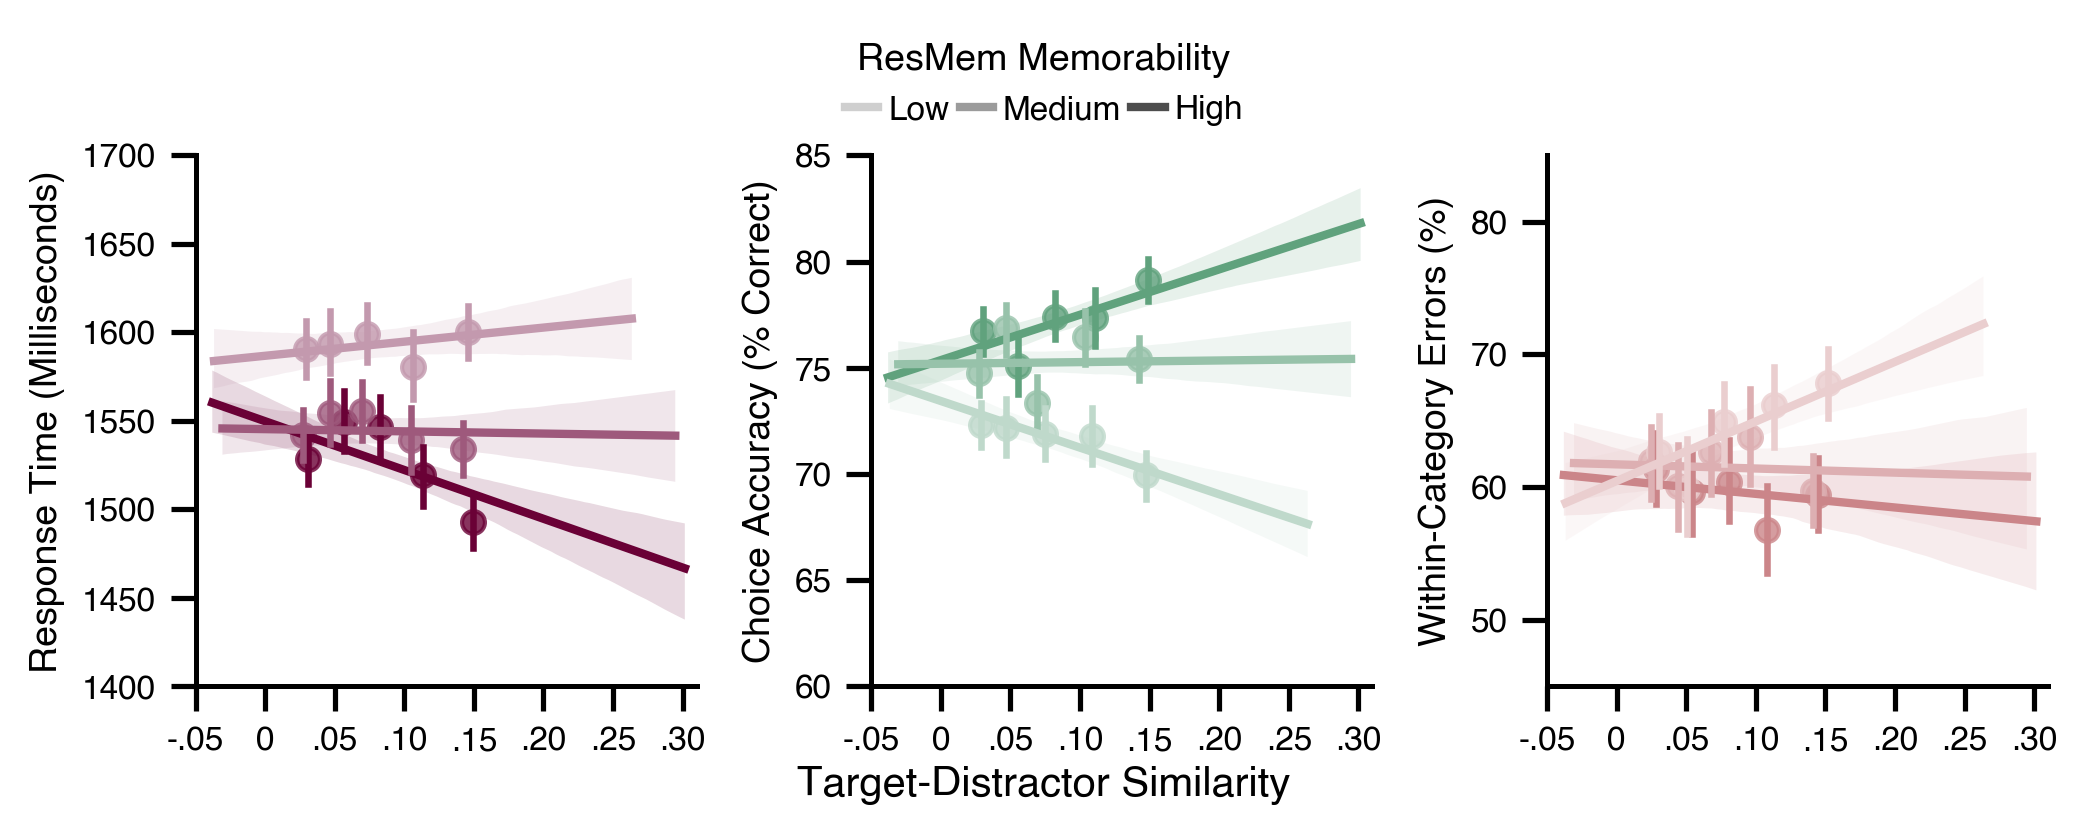

In [24]:
fig = memorability_similarity_facet(
    figsize=(7, 2.5),
    filename_prefix="memorability_similarity_ms"
)

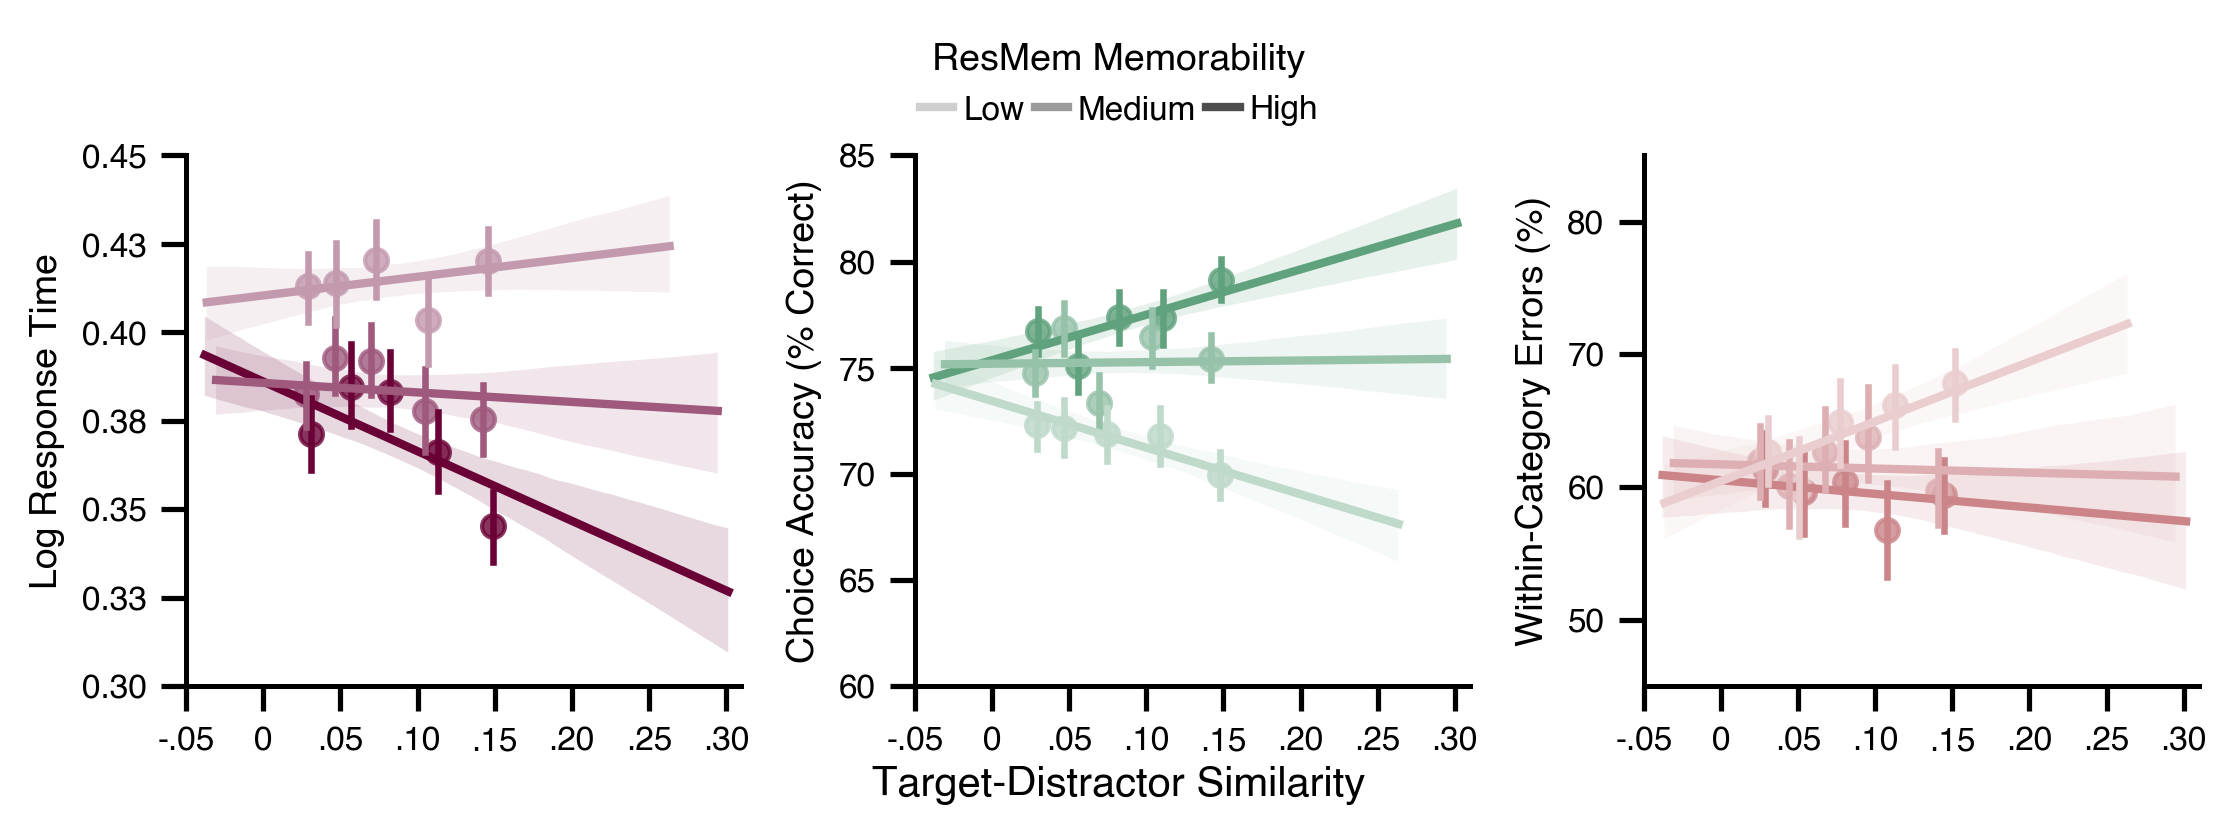

In [25]:
fig_log = memorability_similarity_facet(
    figsize=(7.5, 2.5),
    filename_prefix="memorability_similarity_log_rt",
    rt_mode="log"
)

## <span style="color:#1a73e8">Imagery-Validity Plots</span>

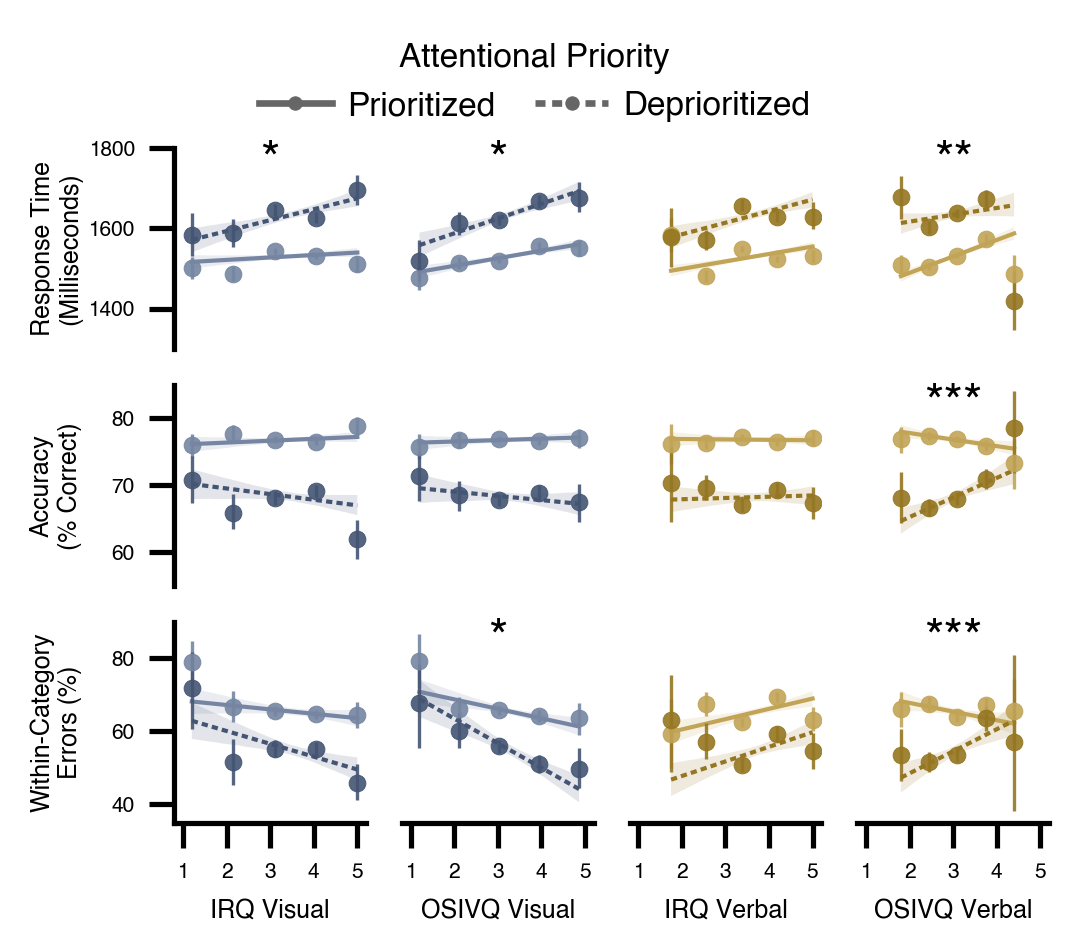

In [21]:
fig_dashed_ms = create_combined_imagery_validity_facet_plot(
    df_correct=df_correct,
    df=df,
    df_errors=df_errors,
    palette_visual=palette_visual,
    palette_verbal=palette_verbal,
    figsize=(5.25, 2.6),
    filename_prefix="combined_imagery_validity_dashed_ms",
    style_mode="dashed",
    rt_mode="ms"
)

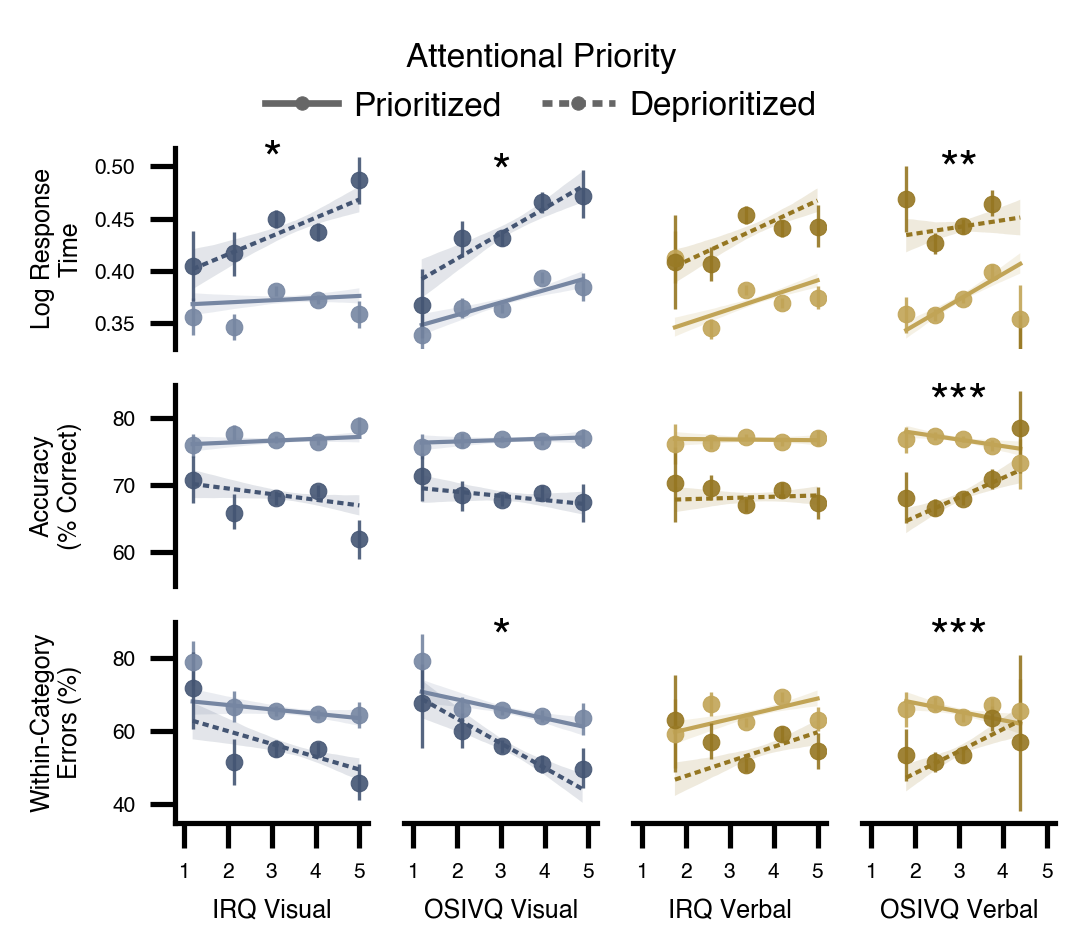

In [22]:
fig_dashed_log = create_combined_imagery_validity_facet_plot(
    df_correct=df_correct,
    df=df,
    df_errors=df_errors,
    palette_visual=palette_visual,
    palette_verbal=palette_verbal,
    figsize=(5.25, 2.6),
    filename_prefix="combined_imagery_validity_dashed_log_rt",
    style_mode="dashed",
    rt_mode="log",
    rt_ylim=None
)

## <span style="color:#1a73e8">Imagery-Memorability-Similarity Plots</span>

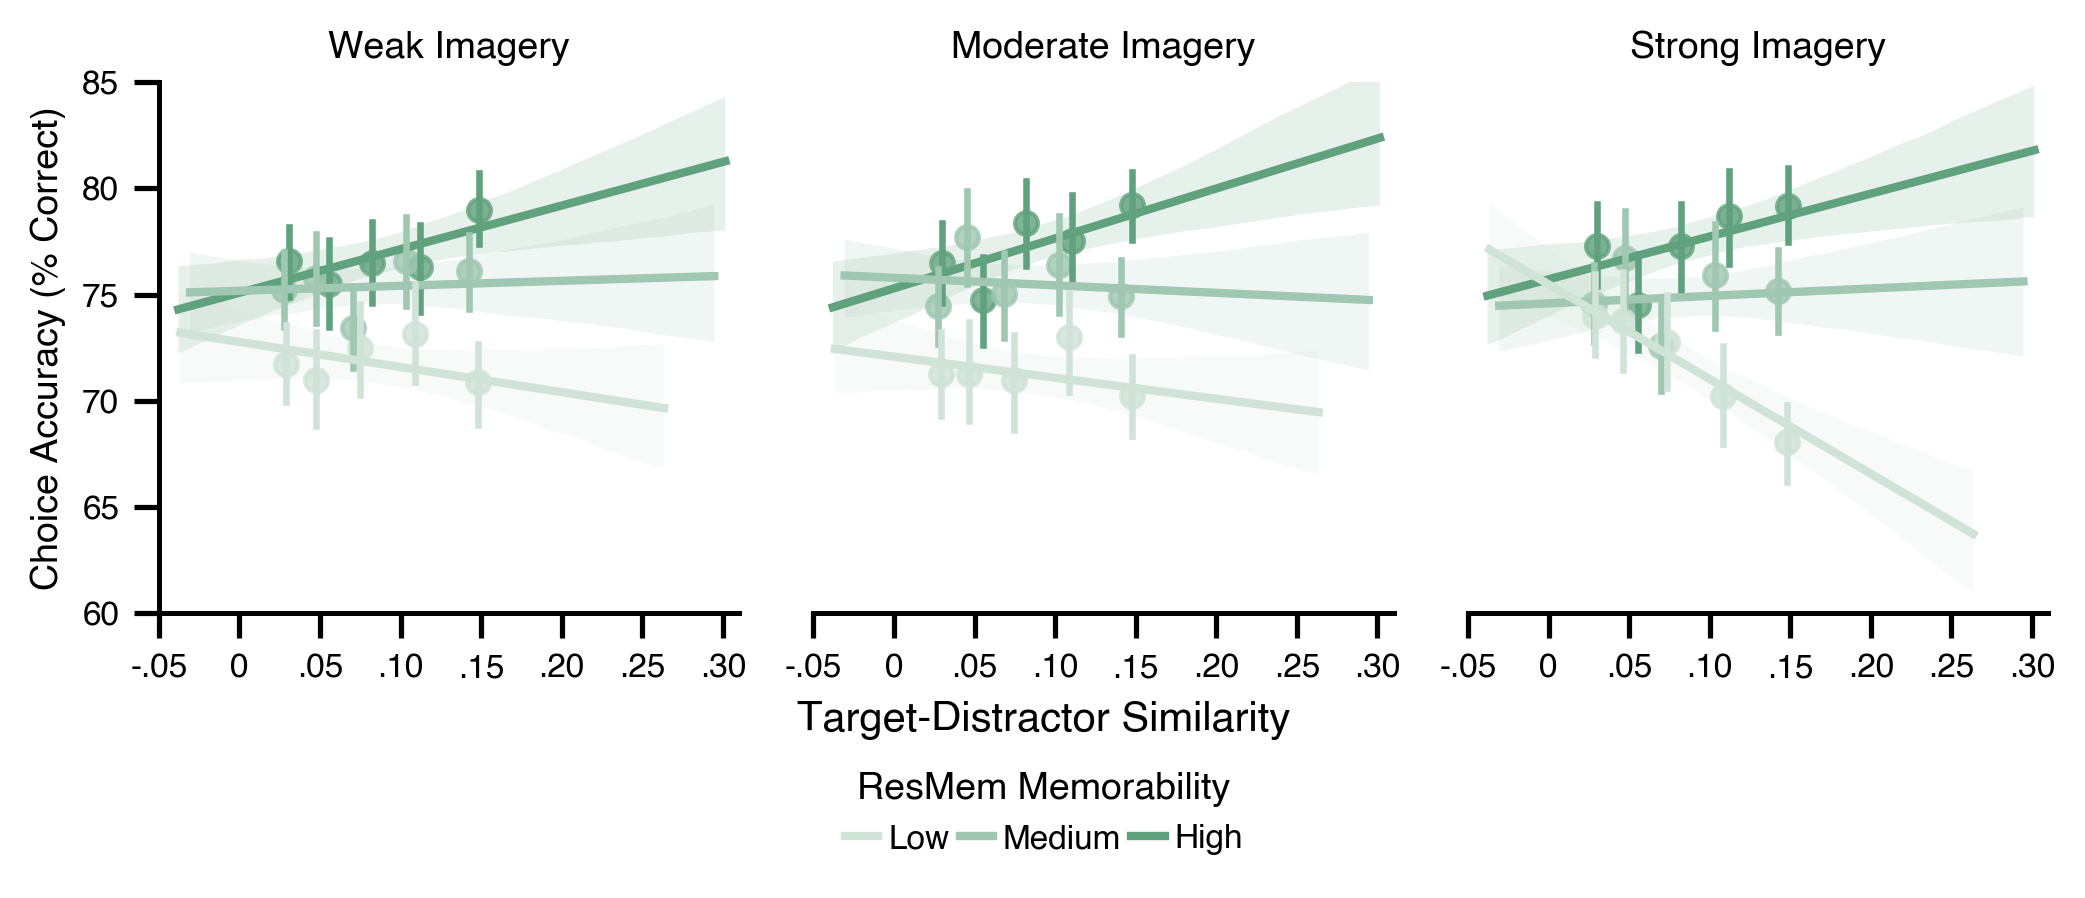

In [23]:
fig_vviq = vviq_accuracy_similarity_memorability_facet(
              df,
              figsize=(7, 2.5),
              vviq_cat_col="vviq_cat" 
)


## <span style="color:#1a73e8">Main Effects Plots: Memorability, Imagery</span>

Total points: 55232, Window size: 11046, Step size: 1104
Total points: 73451, Window size: 14690, Step size: 1469
Total points: 15430, Window size: 3086, Step size: 308


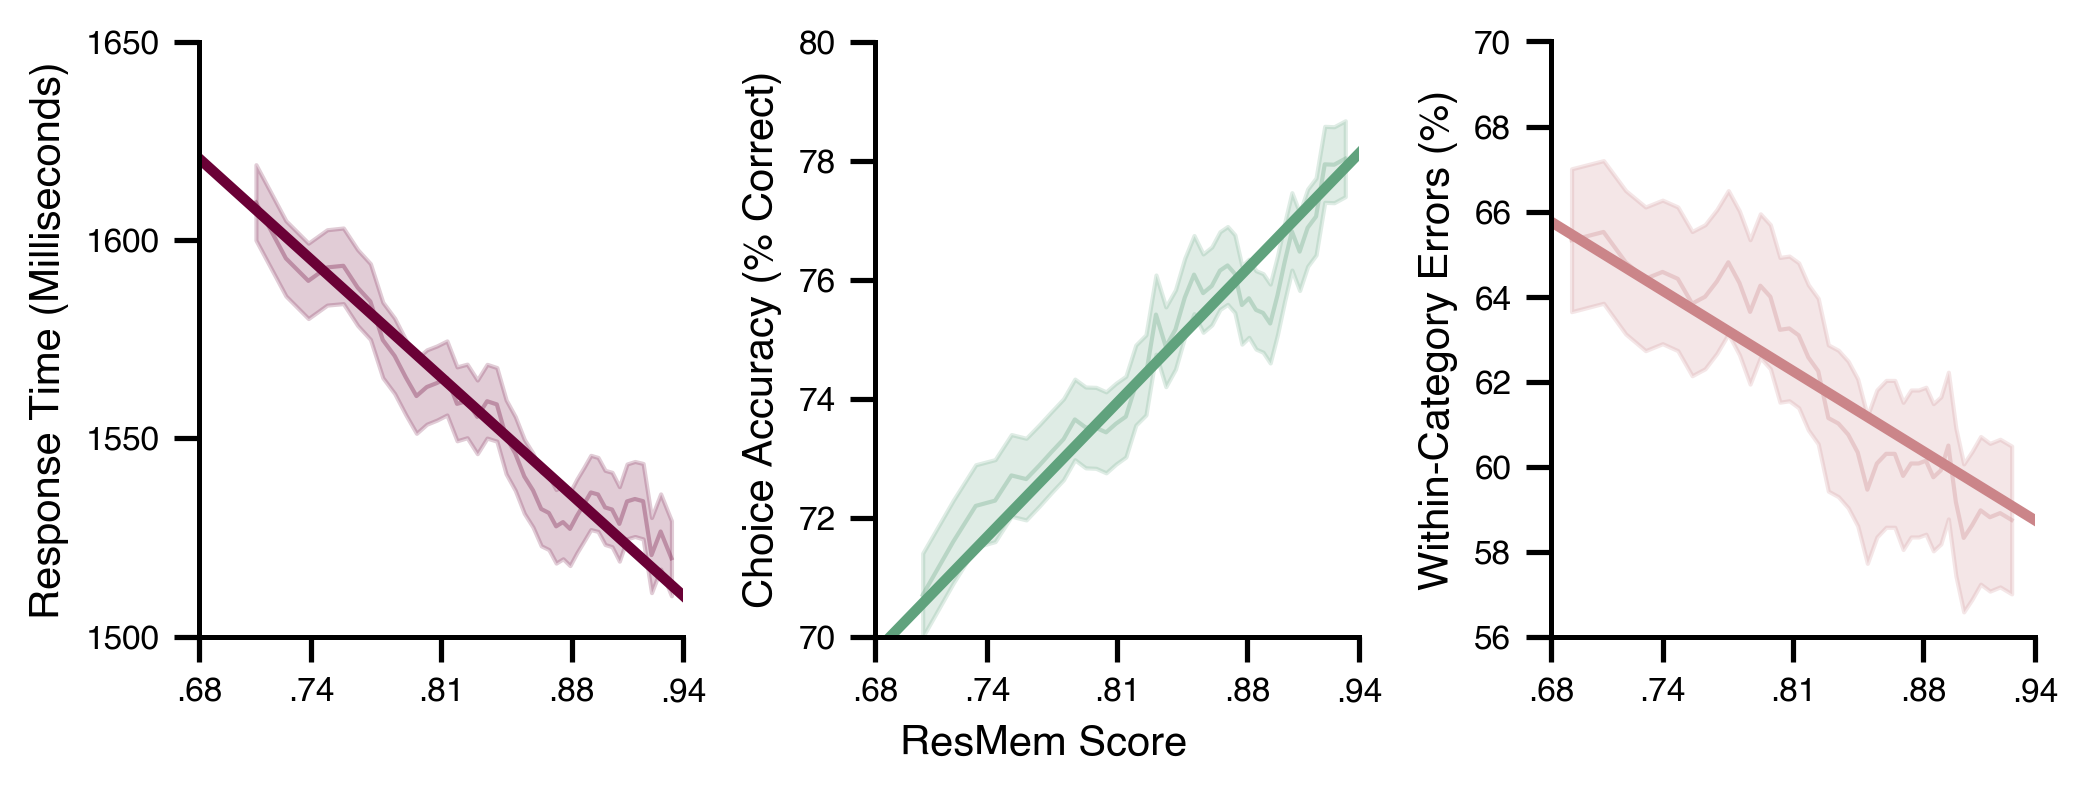

In [26]:
fig, axes = create_memorability_facet(df_correct, df, df_errors, rt_mode="ms")
plt.savefig("plots/memorability_faceted_ms.png", dpi=300, bbox_inches='tight')
plt.show()

Total points: 55232, Window size: 11046, Step size: 1104
Total points: 73451, Window size: 14690, Step size: 1469
Total points: 15430, Window size: 3086, Step size: 308


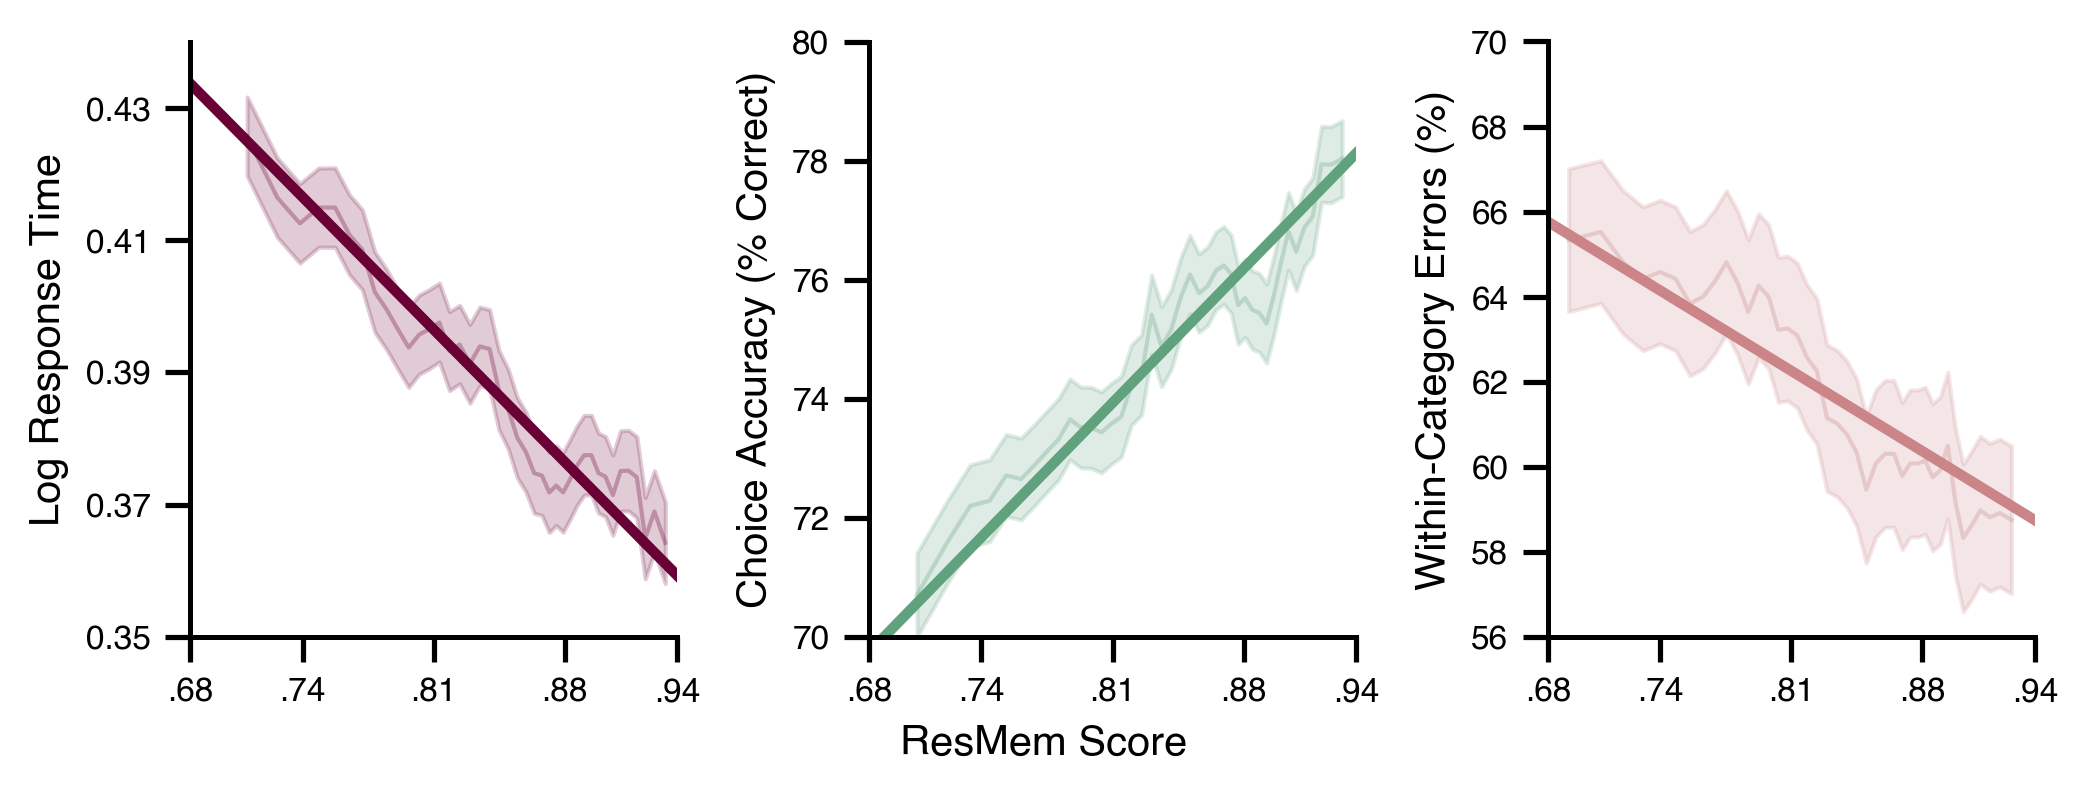

In [27]:
fig, axes = create_memorability_facet(df_correct, df, df_errors, rt_mode="log")
plt.savefig("plots/memorability_faceted_log_rt.png", dpi=300, bbox_inches='tight')
plt.show()

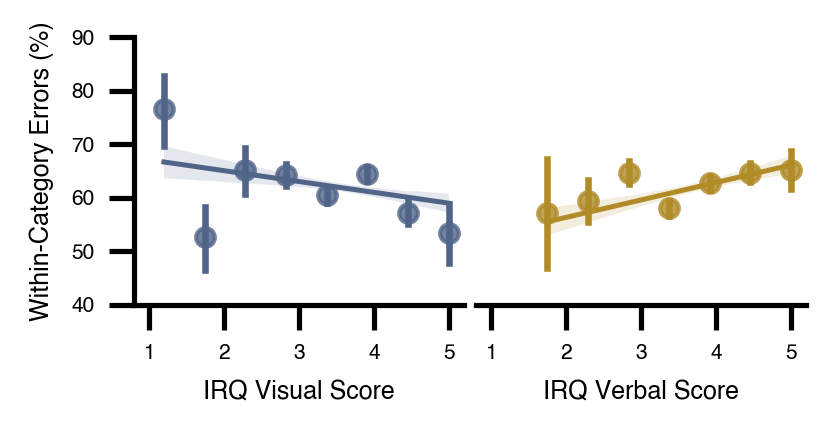

In [28]:
fig, axes = create_irq_visual_verbal_facet(df_errors)
plt.savefig("plots/irq_visual_verbal_facet_one_col.png", dpi=300, bbox_inches='tight')
plt.show()

## <span style="color:#1a73e8">Imagery-Similarity Plots</span>

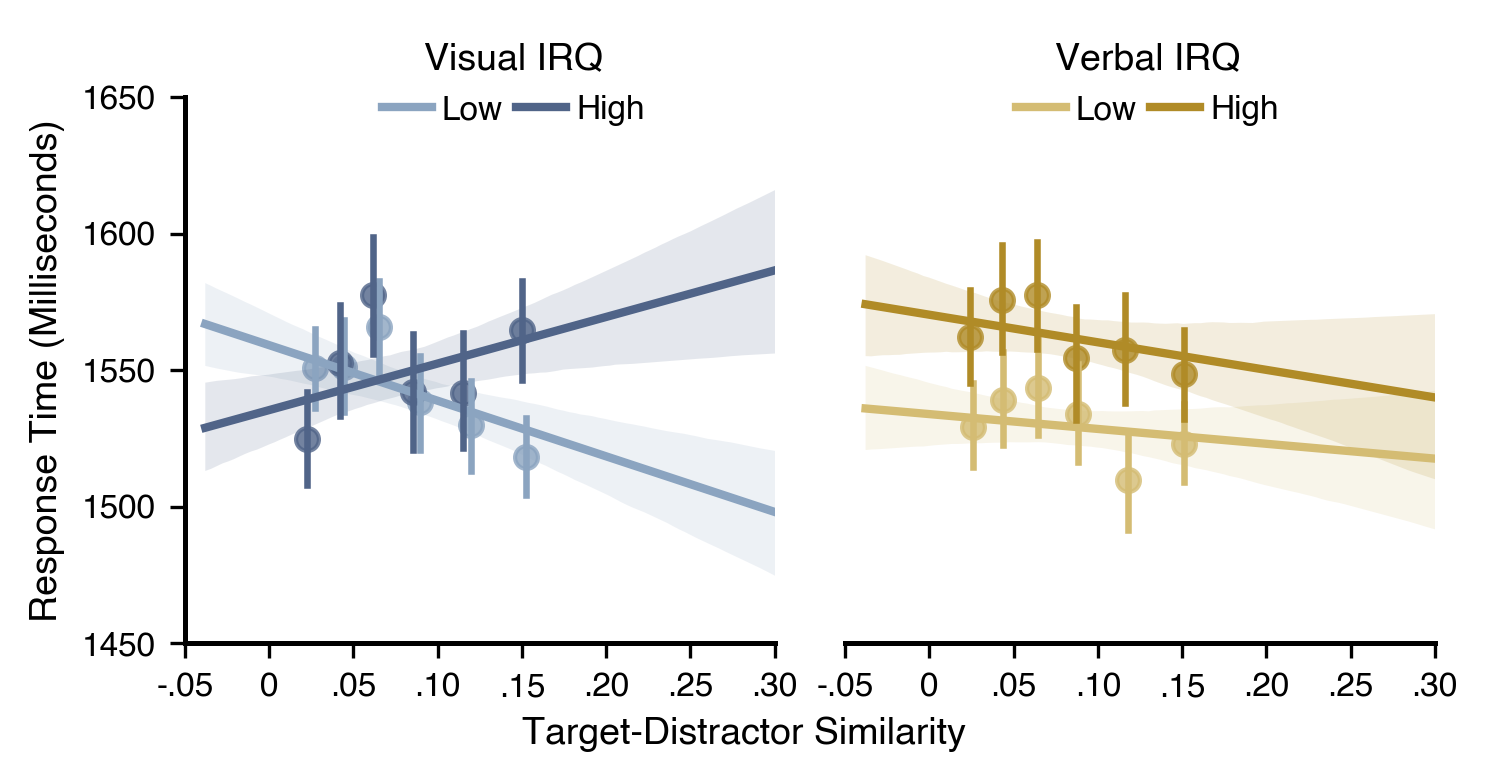

In [29]:
# Two-level plot (low, high only)
fig_two_level = create_irq_regplot_facet(
    df_correct,
    x_bins=6,
    extremes_only=True,
    xlim=(-0.05, 0.30),
    ylim=(1.45, 1.65),
#     x_bins=8,
    figsize=(5, 2.8)
)
plt.savefig('plots/irq_regplot_two_level_ms.png', dpi=300, bbox_inches='tight', pad_inches=0)
plt.savefig('plots/irq_regplot_two_level_ms.pdf', bbox_inches='tight', pad_inches=0)
plt.show()

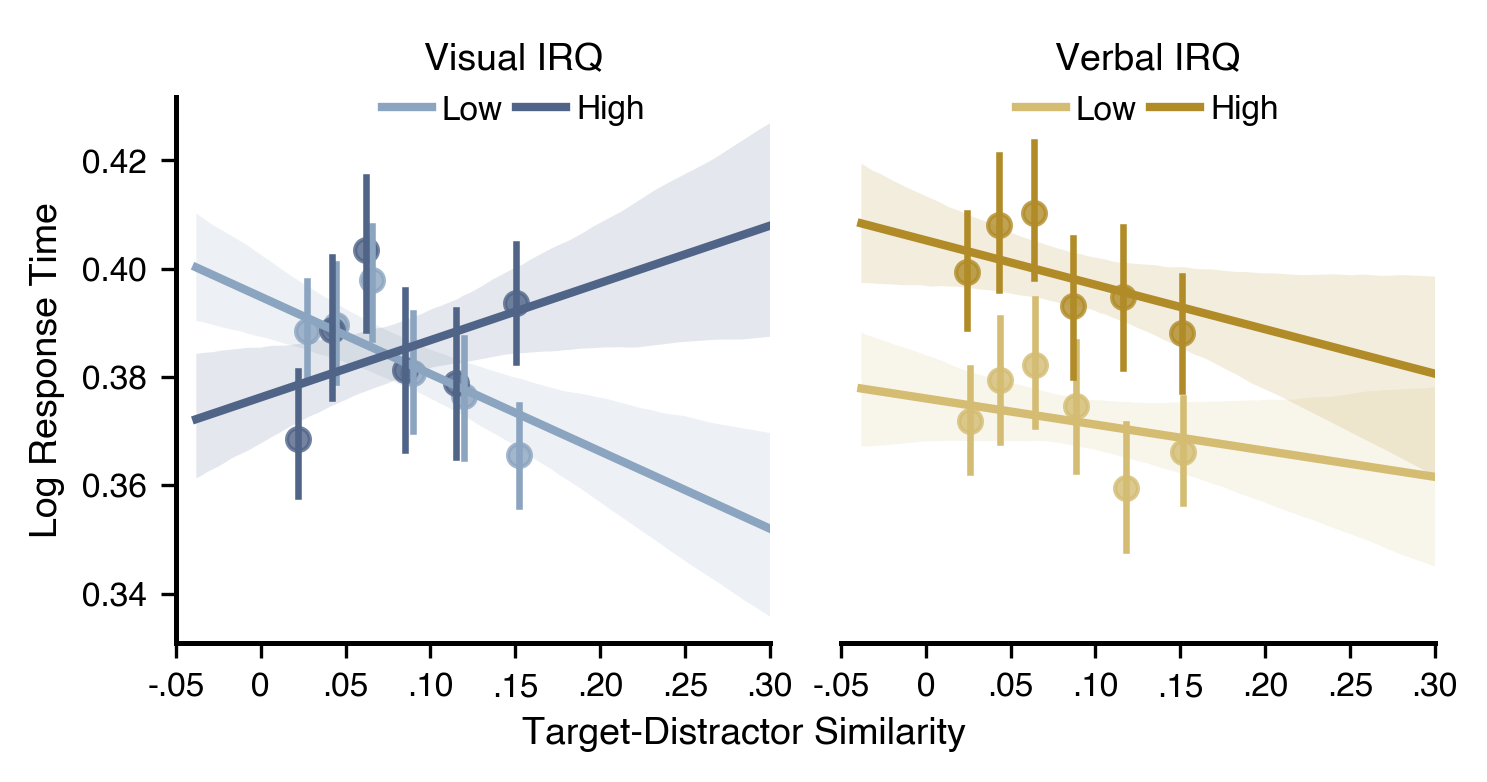

In [30]:
# Two-level plot: low vs. high only, now using log RT
fig_two_level = create_irq_regplot_facet_log(
    df_correct,
    y_col='rt',
    x_bins=6,
    extremes_only=True,
    xlim=(-0.05, 0.30),
    ylim=None,
    figsize=(5, 2.8)
)

plt.savefig(
    'plots/irq_regplot_two_level_log_rt.png',
    dpi=300,
    bbox_inches='tight',
    pad_inches=0
)

plt.savefig(
    'plots/irq_regplot_two_level_log_rt.pdf',
    bbox_inches='tight',
    pad_inches=0
)

plt.show()

## <span style="color:#1a73e8">Distribution Plots</span>

/var/folders/4_/n1p8tswd39b0jr38l2pdhr4r0000gn/T/ipykernel_29171/388369966.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


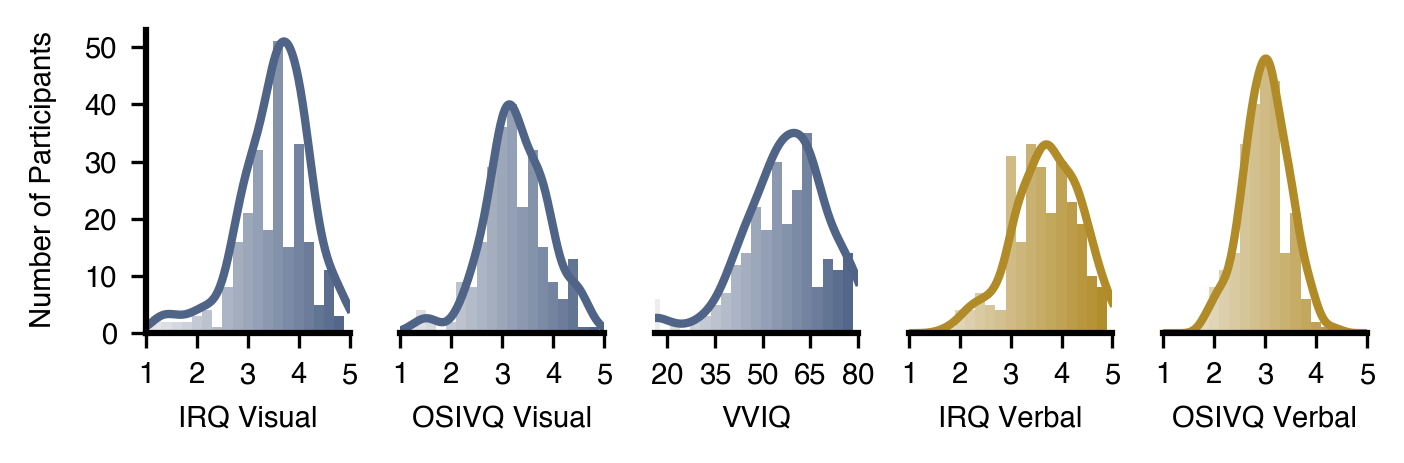

In [31]:
"""
Imagery questionnaire distributions 

"""

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.ticker import FuncFormatter
from scipy.stats import gaussian_kde
from pathlib import Path

# Global figure specs (only change: width/height for 1×5 strip)
TWO_COL_IN         = 7.0        # typical 2-col width
FIG_W_IN           = 0.75 * TWO_COL_IN  # 3/4 of two-column
FIG_H_IN           = FIG_W_IN * 0.25     # height = half of width
DPI                = 300
OUT_DIR            = Path("plots")
OUT_DIR.mkdir(exist_ok=True)

# Global font and line styling
plt.rcParams.update({
    "font.family"   : "Helvetica",
    "font.size"     : 7,    
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "axes.labelsize": 7,
    "axes.titlesize": 7,
    "lines.linewidth": 0.3,
})

df_unique = df.drop_duplicates(subset="participant")

# Color palettes
SLATE_DARK = "#506488"
GOLD_DARK  = "#B08B27"
SLATE_CM   = sns.light_palette(SLATE_DARK, as_cmap=True)
GOLD_CM    = sns.light_palette(GOLD_DARK,  as_cmap=True)

VISUAL_HISTS = [
    ("irq_visual_mean",   "IRQ Visual",   SLATE_DARK, SLATE_CM, (1, 5),   [1, 2, 3, 4, 5]),
    ("osivq_visual_mean", "OSIVQ Visual", SLATE_DARK, SLATE_CM, (1, 5),   [1, 2, 3, 4, 5]),
    ("vviq_sum",          "VVIQ",         SLATE_DARK, SLATE_CM, (16, 80), [20, 35, 50, 65, 80]),
]
VERBAL_HISTS = [
    ("irq_verbal_mean",   "IRQ Verbal",   GOLD_DARK,  GOLD_CM,  (1, 5),   [1, 2, 3, 4, 5]),
    ("osivq_verbal_mean", "OSIVQ Verbal", GOLD_DARK,  GOLD_CM,  (1, 5),   [1, 2, 3, 4, 5]),
]

def add_hist(ax, data, title, dark_col, cmap, xlim, xticks, show_y_ticks):
    # Histogram bins & colors
    counts, bins = np.histogram(data, bins=20, range=xlim)
    centres      = 0.5 * (bins[:-1] + bins[1:])
    bar_cols     = [cmap(Normalize(*xlim)(v)) for v in centres]

    for c, l, r, clr in zip(counts, bins[:-1], bins[1:], bar_cols):
        ax.bar(l, c, width=r - l, color=clr, edgecolor="none", zorder=1)

    # KDE curve
    kde = gaussian_kde(data)
    xx  = np.linspace(*xlim, 200)
    yy  = kde(xx) * counts.max() / kde(xx).max()
    ax.plot(xx, yy, color=dark_col, linewidth=2, zorder=2)

    # Axis limits & ticks
    ax.set_xlim(xlim)
    ax.set_xticks(xticks)
    ax.set_ylim(0, 53)

    # Labels
    ax.set_xlabel(title, fontsize=7)
    if show_y_ticks:
        ax.set_yticks([0, 10, 20, 30, 40, 50])
        ax.tick_params(axis="y", labelsize=7)
        ax.spines["left"].set_linewidth(1.5)
    else:
        ax.set_yticks([])
        ax.spines["left"].set_visible(False)

    # Styling
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_linewidth(1.5)
    ax.tick_params(axis="x", labelsize=7)
    ax.set_ylabel("")

fig = plt.figure(figsize=(FIG_W_IN, FIG_H_IN), dpi=DPI)
gs  = fig.add_gridspec(1, 5, hspace=0.55, wspace=0.25) 

PANELS = VISUAL_HISTS + VERBAL_HISTS 

for i, spec in enumerate(PANELS):
    col, lab, dark, cm, lim, ticks = spec
    ax = fig.add_subplot(gs[0, i])
    add_hist(ax, df_unique[col].dropna(), lab, dark, cm, lim, ticks, show_y_ticks=(i == 0))

# Shared y-axis label
fig.text(0.06, 0.5, "Number of Participants",
         va="center", ha="center", rotation="vertical", fontsize=7)

plt.tight_layout()

for ext in ("png", "pdf"):
    fig.savefig(
        OUT_DIR / f"imagery_distributions_facet_1x5.{ext}",
        dpi=DPI if ext == "png" else None,
        bbox_inches="tight",
        pad_inches=0.05,
        facecolor="white",
    )

plt.show()


test_item values: test_item
img1    36966
img2    36485
Name: count, dtype: int64
Unique tested_image_id: 600
Unique memorability values: 1200
Unique v2 similarity values: 1200
Final memorability data points: 1200
Final v2 similarity data points: 1200
Memorability range: 0.510 to 0.989
V2 similarity range: -0.038 to 0.302


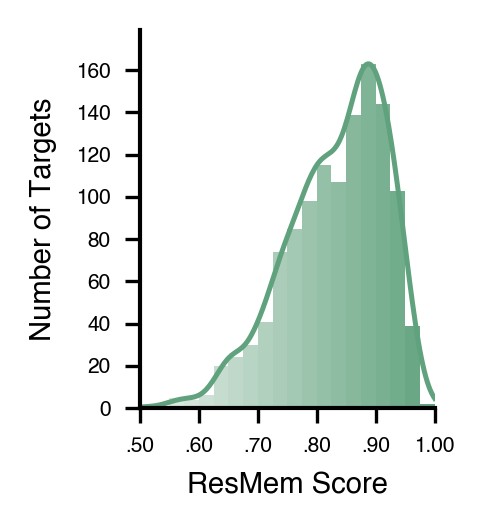

Memorability plot saved as: plots/memorability_distribution_single.png/pdf


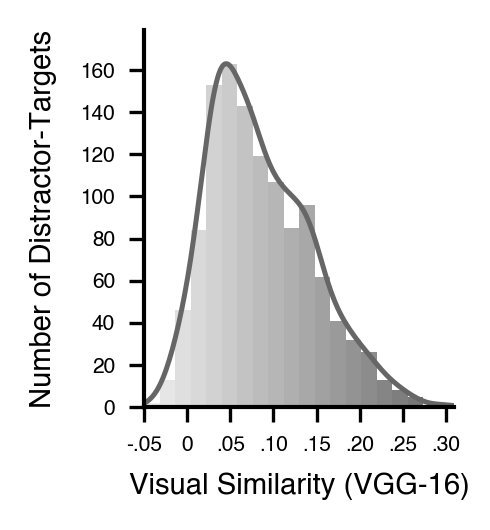

In [32]:
"""
Memorability and similarity distributions

"""

print(f"test_item values: {df['test_item'].value_counts()}")

# Use the test_item column which directly specifies img1 or img2
df["tested_image_id"] = np.where(df["test_item"] == "img1", df["img1"], df["img2"])

print(f"Unique tested_image_id: {df['tested_image_id'].nunique()}")
print(f"Unique memorability values: {df['tested_memorability_resmem'].nunique()}")
print(f"Unique v2 similarity values: {df['v2_sim_dis_test'].nunique()}")


# For memorability: Just the unique memorability values themselves
unique_mem_values = df['tested_memorability_resmem'].dropna().unique()
mem_df = pd.DataFrame({'tested_memorability_resmem': unique_mem_values})

# For v2: Just the unique similarity values themselves  
unique_v2_values = df['v2_sim_dis_test'].dropna().unique()
v2_df = pd.DataFrame({'v2_sim_dis_test': unique_v2_values})

print(f"Final memorability data points: {len(mem_df)}")
print(f"Final v2 similarity data points: {len(v2_df)}")
print(f"Memorability range: {mem_df['tested_memorability_resmem'].min():.3f} to {mem_df['tested_memorability_resmem'].max():.3f}")
print(f"V2 similarity range: {v2_df['v2_sim_dis_test'].min():.3f} to {v2_df['v2_sim_dis_test'].max():.3f}")


def create_single_distribution_plot(values, xlabel, base_color, xlim, xticks, ylabel, filename):
    """Create a single 1.5x1.5 inch distribution plot"""
    
    # Font sizes scaled for 1.5x1.5 inch figures
    plt.rcParams.update({
        "font.family": "Helvetica",
        "font.size": 6,           # Base font size
        "xtick.labelsize": 5,     # X-tick labels
        "ytick.labelsize": 5,     # Y-tick labels
        "lines.linewidth": 0.7,   # Line width
    })
    
    # Create figure
    fig, ax = plt.subplots(figsize=(1.5, 1.6), dpi=300)
    
    # Create histogram and KDE
    counts, bins = np.histogram(values, bins=20, range=xlim)
    centres = 0.5*(bins[:-1] + bins[1:])
    cmap = sns.light_palette(base_color, as_cmap=True)
    norm = Normalize(*xlim)
    bar_cols = [cmap(norm(x)) for x in centres]
    
    # Plot bars
    for c, l, r, clr in zip(counts, bins[:-1], bins[1:], bar_cols):
        ax.bar(l, c, width=r-l, color=clr, align='edge', edgecolor='none', zorder=1)
    
    # Plot KDE
    kde = gaussian_kde(values)
    xx = np.linspace(*xlim, 200)
    yy = kde(xx) * counts.max() / kde(xx).max()
    ax.plot(xx, yy, color=base_color, linewidth=1.2, zorder=2)
    
    # Custom formatter to remove leading zeros from x-axis
    def format_tick(x, pos):
        if x == 0:
            return '0'
        elif x > 0:
            return f'{x:.2f}'.lstrip('0')
        else:  # negative numbers
            return '-' + f'{abs(x):.2f}'.lstrip('0')
    
    from matplotlib.ticker import FuncFormatter
    x_formatter = FuncFormatter(format_tick)
    
    # Set axes properties
    ax.set_xlim(xlim)
    ax.set_xticks(xticks)
    ax.xaxis.set_major_formatter(x_formatter)  # Apply custom formatter to remove leading zeros
    ax.set_ylim(0, int(counts.max() * 1.10))
    ax.set_xlabel(xlabel, fontsize=7)
    ax.set_ylabel(ylabel, fontsize=7)
    
    # Decrease space between y-axis label and plot
    ax.yaxis.set_label_coords(-0.28, 0.5)
    
    # Style spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.spines['left'].set_linewidth(1.0)
    
    # Layout with tighter spacing
    plt.tight_layout(pad=0.2) 
    
    # Save with minimal whitespace
    for ext in ("png", "pdf"):
        plt.savefig(f"plots/{filename}.{ext}",
                    dpi=300 if ext == "png" else None,
                    bbox_inches='tight', pad_inches=0.05, facecolor='white')  # Minimal padding
    
    plt.show()
    plt.close(fig)
    return fig


fig_mem = create_single_distribution_plot(
    values=mem_df['tested_memorability_resmem'],
    xlabel="ResMem Score",
    base_color='#60A27D',
    xlim=(0.5, 1.0),
    xticks=[0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    ylabel="Number of Targets",  # Shortened y-axis label
    filename="memorability_distribution_single"
)

print("Memorability plot saved as: plots/memorability_distribution_single.png/pdf")


fig_v2 = create_single_distribution_plot(
    values=v2_df['v2_sim_dis_test'],
    xlabel="Visual Similarity (VGG-16)",
    base_color='#666666',
    xlim=(-0.05, 0.31),
    xticks=[-0.05, 0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30],
    ylabel="Number of Distractor-Targets",  # Shortened y-axis label
    filename="v2_similarity_distribution_single"
)

## <span style="color:#1a73e8">Imagery Correlation Matrix</span>

In [ ]:
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from matplotlib import cm, colors
from pathlib import Path

# Settings: high-res canvas, font, output paths

plt.rcParams.update({
    'font.family': 'Helvetica',
    'font.size': 12,           # Base font size
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'lines.linewidth': 1.2,
})

OUT_DIR = Path("plots")
OUT_DIR.mkdir(exist_ok=True)

# Plot: correlation matrix

fig, ax = plt.subplots(figsize=(4.5, 4.5), dpi=300)  # Larger canvas

vars_   = ['vviq_sum', 'irq_visual_mean', 'osivq_visual_mean',
           'irq_verbal_mean', 'osivq_verbal_mean']
labels  = ['VVIQ', 'IRQ Visual', 'OSIVQ Visual', 'IRQ Verbal', 'OSIVQ Verbal']
corr    = (df[vars_].copy().set_axis(labels, axis=1)).corr()
mask    = np.triu(np.ones_like(corr, bool), k=1)

# Create bright gray colormap
orig = cm.get_cmap("Greys")
cmap_m = colors.LinearSegmentedColormap.from_list(
             "bright_greys",
             orig(np.linspace(0.1, 0.6, 256)))  # Light to mid-gray

# Heatmap
sns.heatmap(
    corr, mask=mask, cmap=cmap_m,
    vmin=-1, vmax=1, center=0,
    square=True, linewidths=0.4,
    cbar_kws={"location": "left", "pad": 0.02, "shrink": 0.73,
              "fraction": 0.05},
    ax=ax
)

# Colorbar styling
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=9, length=0)
cbar.ax.set_ylabel("Correlation Coefficient",
                   rotation=90, labelpad=4, fontsize=10)

# Annotate correlations
for i in range(len(labels)):
    for j in range(i+1):
        ax.text(j + 0.5, i + 0.5, f"{corr.iat[i,j]:.2f}",
                ha='center', va='center',
                fontsize=10, fontweight='bold', color='black')

# Axis labels (x = bottom, y = right)
ax.set_xticks(np.arange(len(labels)) + 0.5)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)
ax.set_yticks([])
offset = 0.6
for i, lab in enumerate(labels):
    ax.text(i + 0.5 + offset, i + 0.5, lab, ha='left', va='center', fontsize=10)

# Clean up plot appearance
for s in ('top', 'right', 'left', 'bottom'):
    ax.spines[s].set_visible(False)
ax.tick_params(axis='y', length=0)

plt.tight_layout()

# Save
for ext in ('png', 'pdf'):
    fig.savefig(OUT_DIR / f"correlation_matrix.{ext}",
                dpi=300 if ext == 'png' else None,
                bbox_inches='tight', pad_inches=0.05, facecolor='white')

plt.show()


## <span style="color:#1a73e8">Supplemental Figures</span>

In [ ]:
fig_vviq_log, axes_vviq_log = create_vviq_validity_facet(
    df_correct=df_correct,
    df=df, 
    df_errors=df_errors,
    palette=palette_vviq,
    figsize=(6.3, 2.5),
    filename_prefix="vviq_validity_log_rt",
    rt_mode="log",
    rt_ylim=None
)

In [ ]:
fig_osivq_log = imagery_similarity_memorability_facet_3x3(
    df_correct=df_correct,
    df=df,
    df_errors=df_errors,
    imagery_cat_col="osivq_visual_cat",
    imagery_name="Visual Imagery Quality (OSIVQ)",
    highlight_rows=["rt", "accuracy"],
    figsize=(7, 6.2),
    filename_prefix="osivq_similarity_memorability_3x3_log_rt",
    rt_mode="log",
    rt_ylim=(0.26, 0.50)
)

In [ ]:
fig_vviq_log = imagery_similarity_memorability_facet_3x3(
    df_correct=df_correct,
    df=df,
    df_errors=df_errors,
    imagery_cat_col="vviq_cat",
    imagery_name="Visual Imagery Vividness (VVIQ)",
    highlight_rows=["accuracy"],
    figsize=(7, 6.2),
    filename_prefix="vviq_similarity_memorability_3x3_log_rt",
    rt_mode="log",
    rt_ylim=(0.26, 0.50)
)